# Game Player Analysis — Final Data Science Review

**Executed primary deliverable.** In this notebook, I predict
`winRankPercentage`, the player's team's normalized final ranking from 0 (last
place) to 1 (first place), using post-match statistics. Each row describes one
player, while the team-level target is repeated for the observed players from
that team.

I prioritize sound interpretation and traceability: every modeled result is
out-of-fold, I group by `gameId`, and I keep the official unlabeled May test
file outside every model-selection decision.

## 1. Official setting, metric, and questions

- **Train:** 50,000 rows assigned to January–April 2024.
- **Test:** 5,000 rows assigned to May 2024.
- **Primary metric:** MAE, complemented by RMSE and R².
- **Model question:** what post-match accuracy do I obtain from individual
  variables, and how much comes from `killRank`?
- **Product question:** do mobility, combat, and resource behaviours remain
  informative without the post-match ranking?

The brief states that `date` is the match date. I test that definition rather
than assume it is true. `maxRank` defines the reported ranking grid; it is
neither the actual player count nor the number of observed rows per match.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/game-player-analysis-matplotlib")

import pandas as pd
from IPython.display import Image, Markdown, display

from game_player_analysis.inference import predict_frame
from game_player_analysis.logging_config import configure_logging
from game_player_analysis.pipeline import run_final_analysis

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
configure_logging()

Matplotlib is building the font cache; this may take a moment.


<Logger game_player_analysis (INFO)>

## 2. Reproducible execution and reviewed artifacts

By default, I load the reviewed published artifacts so this notebook stays fast
to inspect and its figures remain visible without re-fitting CatBoost. I set
`REBUILD_ARTIFACTS = True` only when I want to recompute the full pipeline from
the private raw CSV files: validation, cleaning, EDA, feature engineering,
GroupKFold, four model families, a frozen grouped holdout, bounded tuning,
ablations, drift, diagnostics, the final model, its manifest, and the
submission. I use modeling seed 42 and retain the data SHA-256 fingerprints in
the manifest.

In [2]:
REBUILD_ARTIFACTS = False

if REBUILD_ARTIFACTS:
    results = run_final_analysis(tuning_iterations=8)
else:
    import json

    from game_player_analysis.cleaning import clean_ranking_sentinels
    from game_player_analysis.config import ARTIFACT_DIR
    from game_player_analysis.data import load_train_test

    table_names = (
        "dataset_summary",
        "data_quality",
        "date_integrity",
        "sampling_coverage",
        "numeric_profile",
        "game_modes",
        "kpi_evaluation",
        "feature_profiles",
        "distribution_shift",
        "categorical_shift",
        "categorical_shift_detail",
        "fold_audit",
        "final_holdout_audit",
        "final_holdout_evaluation",
        "holdout_audit",
        "holdout_performance",
        "model_parameter_audit",
        "pre_audit_configuration_comparison",
        "initial_model_comparison",
        "model_comparison",
        "model_fold_uncertainty",
        "feature_ablation",
        "scenario_comparison",
        "tuning_trials",
        "tuning_comparison",
        "subgroup_errors",
        "largest_errors",
        "permutation_importance",
        "shap_global_importance",
        "shap_sample",
        "shap_values",
    )
    tables = {
        name: pd.read_csv(ARTIFACT_DIR / "metrics" / f"{name}.csv")
        for name in table_names
    }
    for name in ("target_grid", "adversarial_validation", "drift_limitations"):
        tables[name] = pd.read_csv(
            ARTIFACT_DIR / "metrics" / f"{name}.csv", index_col=0
        )["value"]

    _, test_raw = load_train_test()
    metadata_dir = ARTIFACT_DIR / "metadata"
    selection_decision = json.loads(
        (metadata_dir / "final_selection_decision.json").read_text(encoding="utf-8")
    )
    tuning_decision = json.loads(
        (metadata_dir / "tuning_decision.json").read_text(encoding="utf-8")
    )
    figure_names = {
        "figure_date_integrity": "01_date_integrity.png",
        "figure_data_quality": "02_data_quality.png",
        "figure_sampling": "03_sampling_structure.png",
        "figure_target": "04_target_distribution.png",
        "figure_profiles": "05_feature_target_profiles.png",
        "figure_correlations": "06_targeted_correlations.png",
        "figure_validation": "07_validation_strategies.png",
        "figure_drift": "07b_train_test_drift.png",
        "figure_ablation": "08_feature_ablation.png",
        "figure_models": "09_model_diagnostics.png",
        "figure_tuning": "10_tuning_results.png",
        "figure_errors": "11_error_diagnostics.png",
        "figure_importance": "12_permutation_importance.png",
        "figure_shap": "13_catboost_shap_summary.png",
    }
    paths = {
        "model": ARTIFACT_DIR / "model.joblib",
        "manifest": ARTIFACT_DIR / "model_manifest.json",
        "submission": PROJECT_ROOT / "data" / "output" / "submission.csv",
        "tuning_decision": metadata_dir / "tuning_decision.json",
        "selection_decision": metadata_dir / "final_selection_decision.json",
        **{
            f"table_{name}": ARTIFACT_DIR / "metrics" / f"{name}.csv"
            for name in (*table_names, "target_grid", "adversarial_validation", "drift_limitations")
        },
        **{
            key: ARTIFACT_DIR / "figures" / filename
            for key, filename in figure_names.items()
        },
    }
    results = {
        "test": clean_ranking_sentinels(test_raw),
        "winner": selection_decision["selected_configuration"],
        "tables": tables,
        "paths": paths,
        "tuning_decision": tuning_decision,
        "selection_decision": selection_decision,
    }

tables = results["tables"]
display(Markdown(f"**Published model: {results['winner']}**"))

**Published model: CatBoost**

## 3. Loading, data contract, and cleaning

In [3]:
display(tables["dataset_summary"])
display(tables["data_quality"].pivot(index="check", columns="dataset", values="rows"))

,Unnamed: 0,train,test
0,rows,50000,5000
1,columns,30,29
2,matches,30983,4431
3,game_modes,16,10
4,missing_cells,0,0
5,exact_duplicates,0,0
6,date_min,2024-01-01 00:00:00,2024-05-01 00:00:00
7,date_max,2024-04-30 00:00:00,2024-05-31 00:00:00
8,has_target,True,False


dataset,test,train
check,,
combat_without_distance,5,102
exact_duplicates,0,0
invalid_gameId,10,93
invalid_playerId,14,93
invalid_teamId,8,87
killPts_conditional_zero,3000,29840
kills_without_damage,5,53
missing_cells,0,0
rankPts_-1,1888,19191


I find neither raw missing values nor exact duplicates. That does not mean every
value is semantically available: `rankPts=-1` is a documented sentinel, and
`killPts=0` and `winPts=0` are missing when the `rankPts` system is active. I
convert them to missing values and add availability flags without dropping rows.
I exclude these scores from the final model so that I do not mix ranking systems.

,dataset,check,rows,pct
2,train,invalid_playerId,93,0.186000
3,train,invalid_teamId,87,0.174000
4,train,invalid_gameId,93,0.186000
5,train,rankPts_-1,19191,38.382000
6,train,killPts_conditional_zero,29840,59.680000
7,train,winPts_conditional_zero,29840,59.680000
8,train,kills_without_damage,53,0.106000
9,train,combat_without_distance,102,0.204000
12,test,invalid_playerId,14,0.280000
13,test,invalid_teamId,8,0.160000


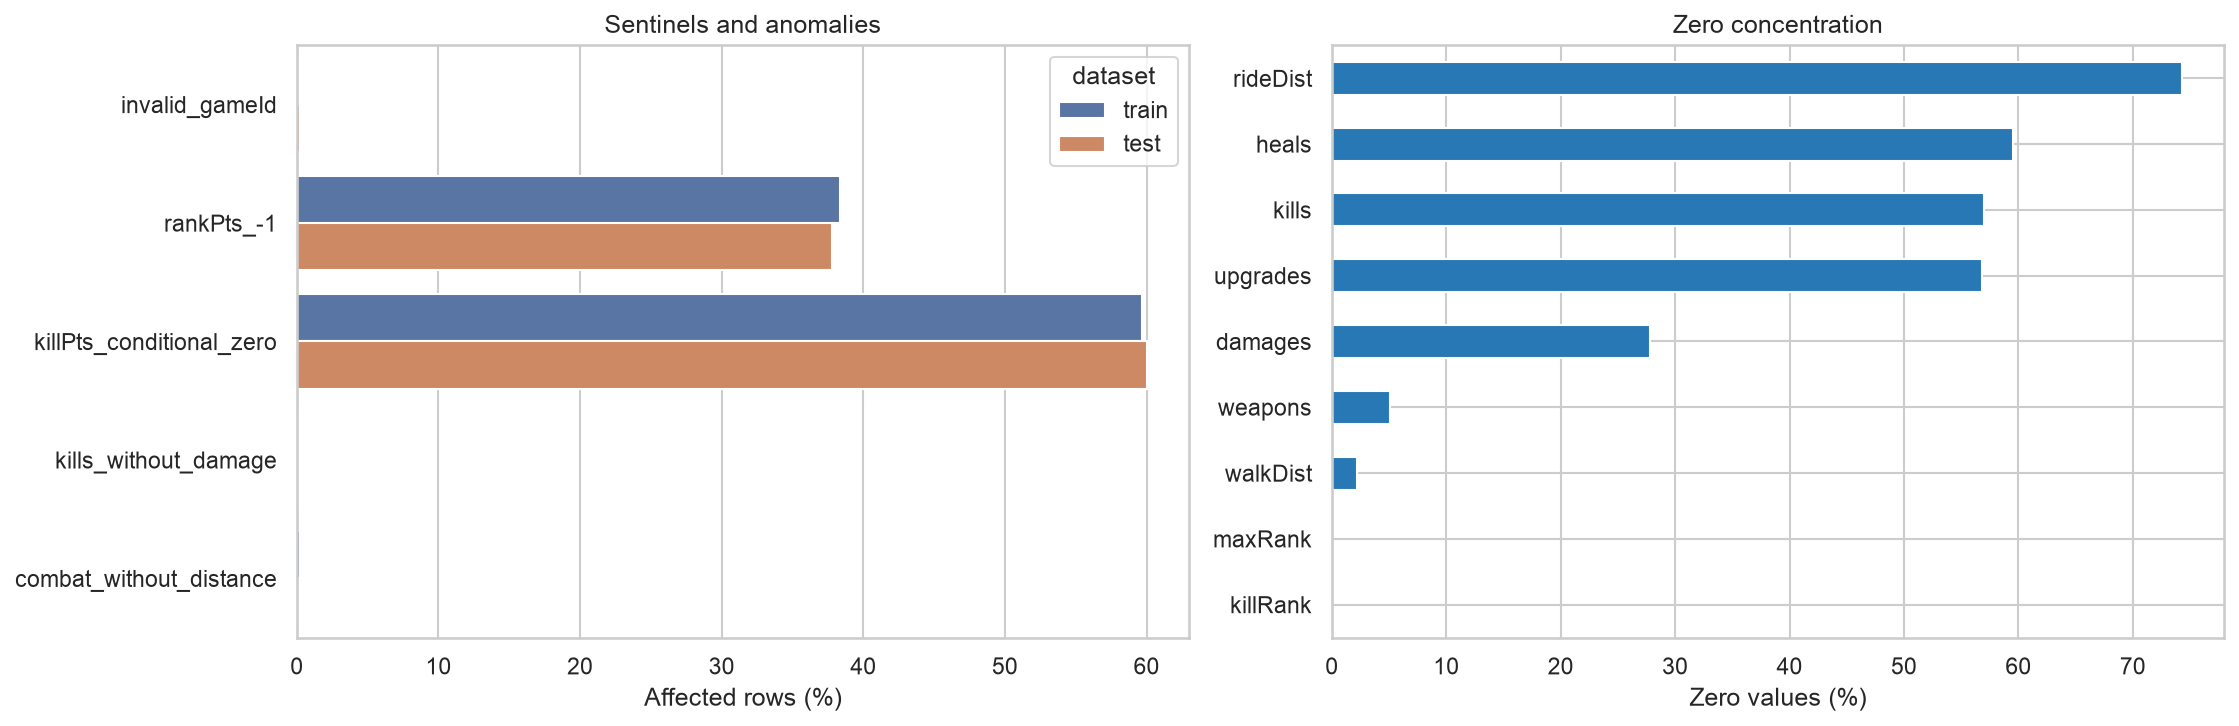

In [4]:
quality = tables["data_quality"]
display(quality.loc[quality["check"].str.contains("Pts|without|invalid")])
display(Image(filename=str(results["paths"]["figure_data_quality"])))

## 4. Date and sampling audit

,dataset,rows,valid_game_ids,games,multirow_games,multirow_games_with_multiple_dates_pct,median_within_game_span_days,p95_within_game_span_days,max_within_game_span_days,date_min,date_max,unique_dates
0,train,50000,49907,30927,13464,100.000000,45.026931,99.528735,119.302646,2024-01-01,2024-04-30,50000
1,test,5000,4990,4425,521,100.000000,9.067814,22.930586,28.949790,2024-05-01,2024-05-31,5000


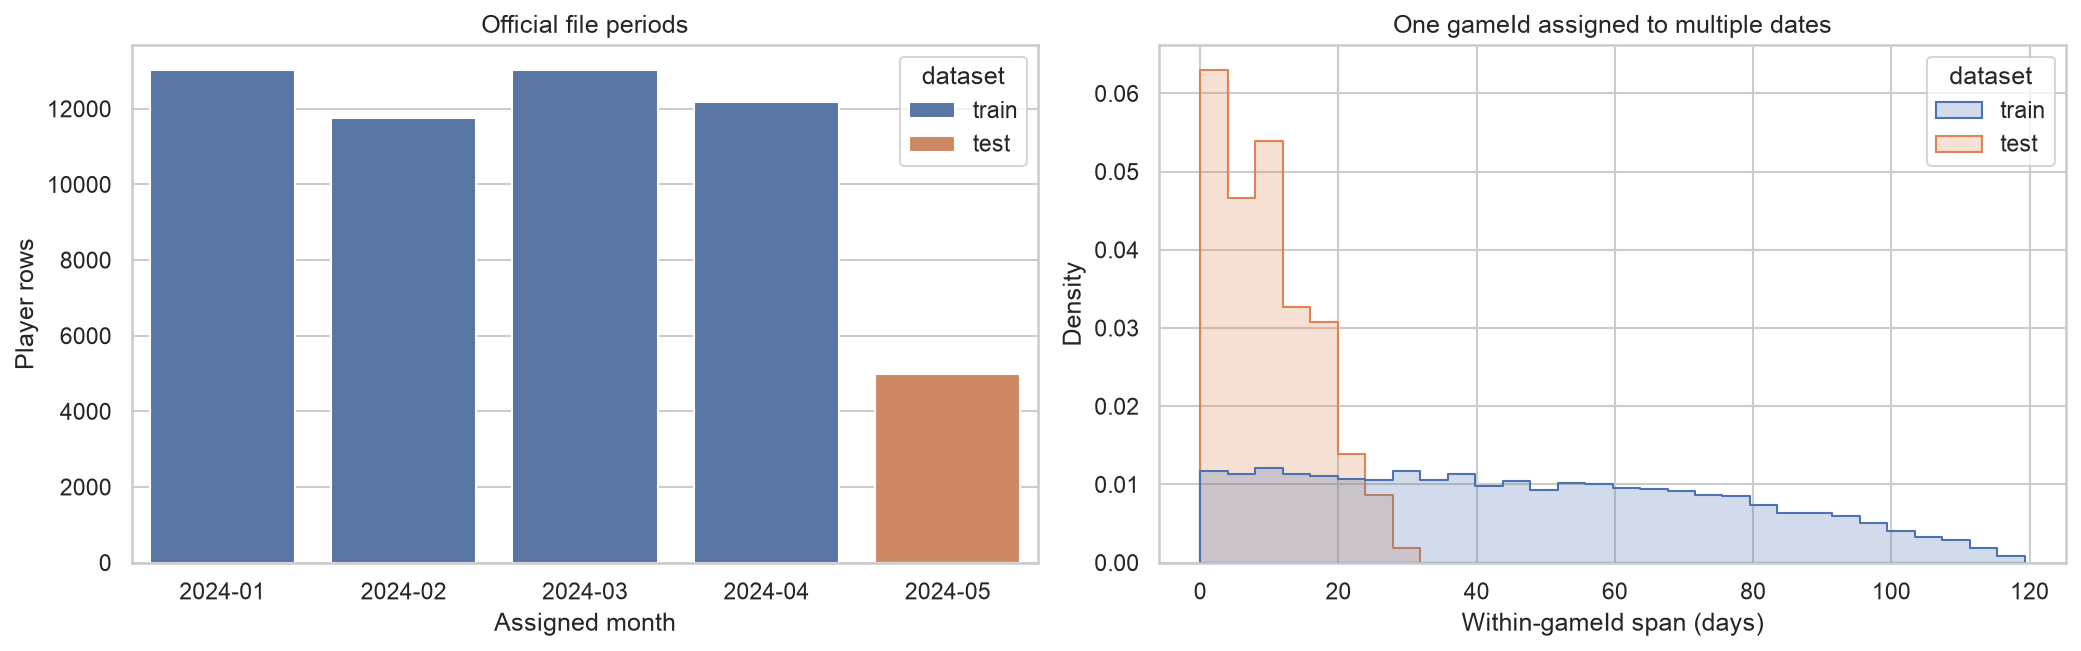

In [5]:
display(tables["date_integrity"])
display(Image(filename=str(results["paths"]["figure_date_integrity"])))

**My temporal-audit conclusion.** In 100% of valid multi-row `gameId`s, dates
differ between players; the median span is about 45 days in train. Dates are
therefore incompatible with their official row-level definition. I cannot
observe the technical cause in the files, so I call them inconsistent/corrupted
rather than invent an explanation. Time is only a pseudo-temporal stress test.

,dataset,games,mean_observed_players_per_game,max_observed_players_per_game,observed_game_teams,singleton_team_pct,rows_with_observed_teammate_pct
0,train,30983,1.613788,8,49411,98.824148,2.340000
1,test,4431,1.128413,4,4974,99.477282,1.040000


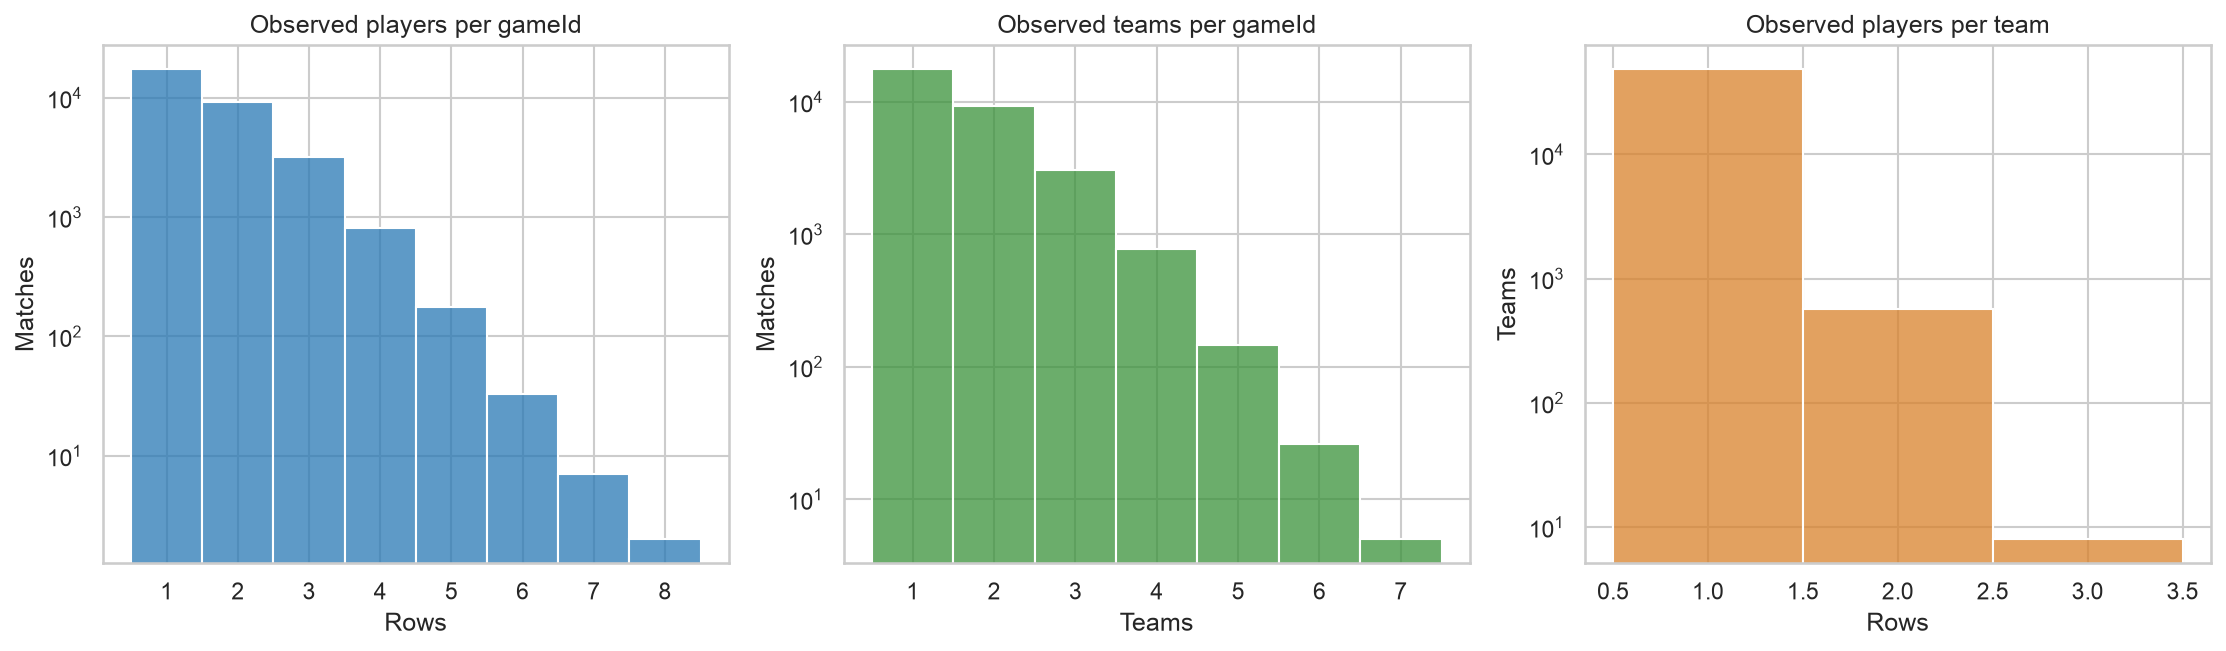

In [6]:
display(tables["sampling_coverage"])
display(Image(filename=str(results["paths"]["figure_sampling"])))

Only about 2.34% of train rows have an observed teammate, and nearly 98.82% of
`(gameId, teamId)` groups are singletons. I therefore **reject** team- and
lobby-level aggregates: they would mostly measure the sampling mechanism, not
complete team performance.

## 5. Train/test drift

,feature,train_mean,test_mean,standardized_mean_difference,ks_statistic,ks_pvalue,psi,wasserstein_over_train_std,train_zero_pct,test_zero_pct,zero_pct_point_change,train_p95,test_p95
0,damages,130.002242,126.041640,-0.023469,0.013120,0.410973,0.005085,0.029847,27.810000,27.280000,-0.530000,457.000000,444.725000
1,maxRank,44.396660,44.597000,0.008445,0.010040,0.745335,0.003538,0.010157,0.000000,0.000000,0.000000,97.000000,97.000000
2,resource_activity,6.145900,6.108800,-0.006921,0.010860,0.653128,0.002346,0.015860,5.078000,5.040000,-0.038000,17.000000,16.000000
3,walk_distance_per_match_minute,44.044220,43.966128,-0.001743,0.008060,0.926949,0.001807,0.008345,2.204000,2.280000,0.076000,130.776114,131.777471
4,weapons,3.664060,3.659200,-0.001971,0.010820,0.657677,0.001797,0.016649,5.116000,5.040000,-0.076000,8.000000,8.000000
5,killRank,47.576260,47.926600,0.012777,0.010140,0.734303,0.001051,0.013159,0.000000,0.000000,0.000000,91.000000,91.000000
6,walkDist,"1,155.221535","1,146.163054",-0.007655,0.008800,0.869905,0.001041,0.009669,2.204000,2.280000,0.076000,"3,384.000000","3,361.100000"
7,upgrades,1.104860,1.091400,-0.007858,0.007040,0.976760,0.000849,0.017643,56.864000,56.360000,-0.504000,5.000000,5.000000
8,damage_per_kill,53.572314,53.244604,-0.004424,0.004920,0.999881,0.000792,0.007814,57.072000,57.180000,0.108000,190.600000,189.905000
9,combat_activity,1.809560,1.768000,-0.015199,0.007060,0.976107,0.000717,0.016165,45.468000,45.460000,-0.008000,7.000000,7.000000


,feature,psi,total_variation_distance,largest_shift_category,largest_percentage_point_change,train_unique,test_unique,test_only_categories
0,gameType,0.008441,0.010840,squad-fpp,0.506000,16,10,0
1,mode_family,0.001211,0.003900,squad,0.310000,4,4,0
2,ranking_system,0.000556,0.006220,legacy,-0.622000,3,3,0


method            standardized logistic adversarial validation
folds                                                        5
roc_auc_mean                               0.49324817000000004
roc_auc_std                               0.005420325940107311
roc_auc_min                                          0.4846618
roc_auc_max                                0.49884680000000003
interpretation                    weak multivariate separation
Name: value, dtype: object

data_drift_train_vs_test                                measurable without target
performance_or_concept_drift    not measurable: official test target is unavai...
temporal_drift                    not interpretable: date conflicts within gameId
decision_rule                   effect sizes first; KS p-values are descriptiv...
Name: value, dtype: object

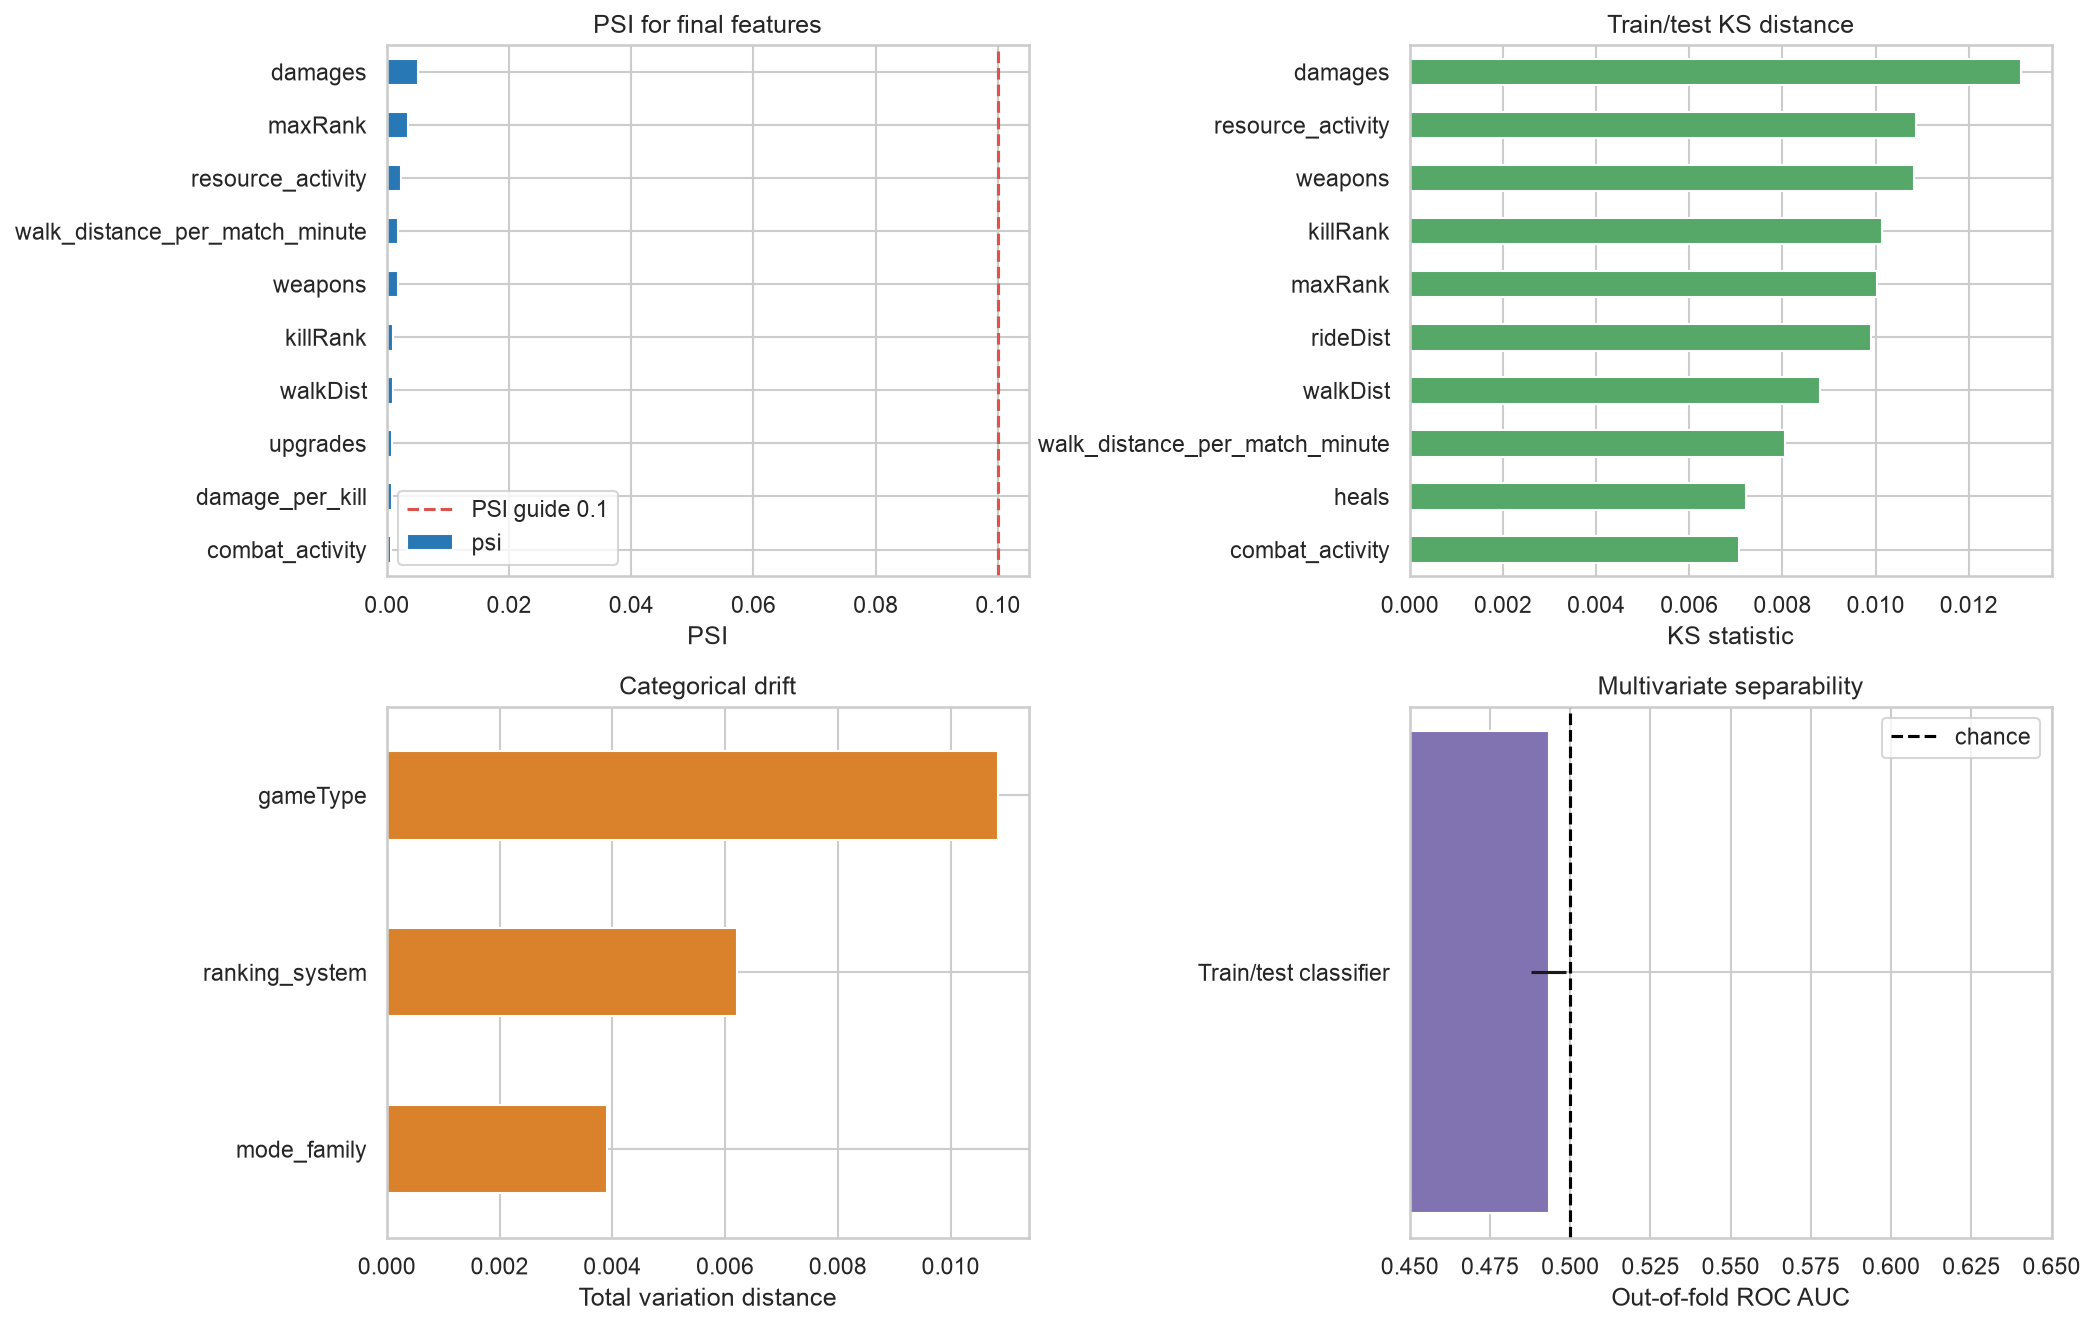

In [7]:
display(tables["distribution_shift"].head(16))
display(tables["categorical_shift"])
display(tables["adversarial_validation"])
display(tables["drift_limitations"])
display(Image(filename=str(results["paths"]["figure_drift"])))

I measure drift with PSI, KS, normalized Wasserstein distance, zero-mass
changes, categorical shifts, and adversarial validation. The maximum numeric
PSI is about 0.0051, the maximum categorical PSI is 0.0084, and adversarial ROC
AUC is 0.493: I detect no material drift in the measured feature contract. This
does not prove identical distributions. Without test targets, performance and
concept drift remain unknown; with inconsistent dates, temporal drift is not
interpretable.

## 6. Exploratory analysis and hypotheses

,value
target_mean,0.472333
target_median,0.457850
target_std,0.307449
target_zero_rows,"2,450.000000"
target_one_rows,"1,430.000000"
unique_target_values,"1,445.000000"
grid_distance_median,0.000800
grid_distance_p95,0.003200
grid_distance_max,0.005000
rows_within_0.0001_of_grid,"10,380.000000"


,Unnamed: 0,zero_pct,mean,median,p95,p99,max,spearman_target
0,walkDist,2.204000,"1,155.221535",683.750000,"3,384.000000","4,395.020000","11,260.000000",0.866437
1,killRank,0.000000,47.576260,47.000000,91.000000,96.000000,100.000000,-0.714684
2,upgrades,56.864000,1.104860,0.000000,5.000000,7.000000,14.000000,0.681032
3,weapons,5.116000,3.664060,3.000000,8.000000,10.000000,73.000000,0.664606
4,heals,59.542000,1.376980,0.000000,7.000000,13.000000,41.000000,0.563679
5,damages,27.810000,130.002242,84.700000,457.000000,766.602000,"3,725.000000",0.449022
6,rideDist,74.258000,602.279772,0.000000,"4,032.000000","6,868.100000","31,290.000000",0.432890
7,kills,56.966000,0.921040,0.000000,4.000000,7.000000,35.000000,0.424812
8,maxRank,0.000000,44.396660,30.000000,97.000000,99.000000,100.000000,0.045750


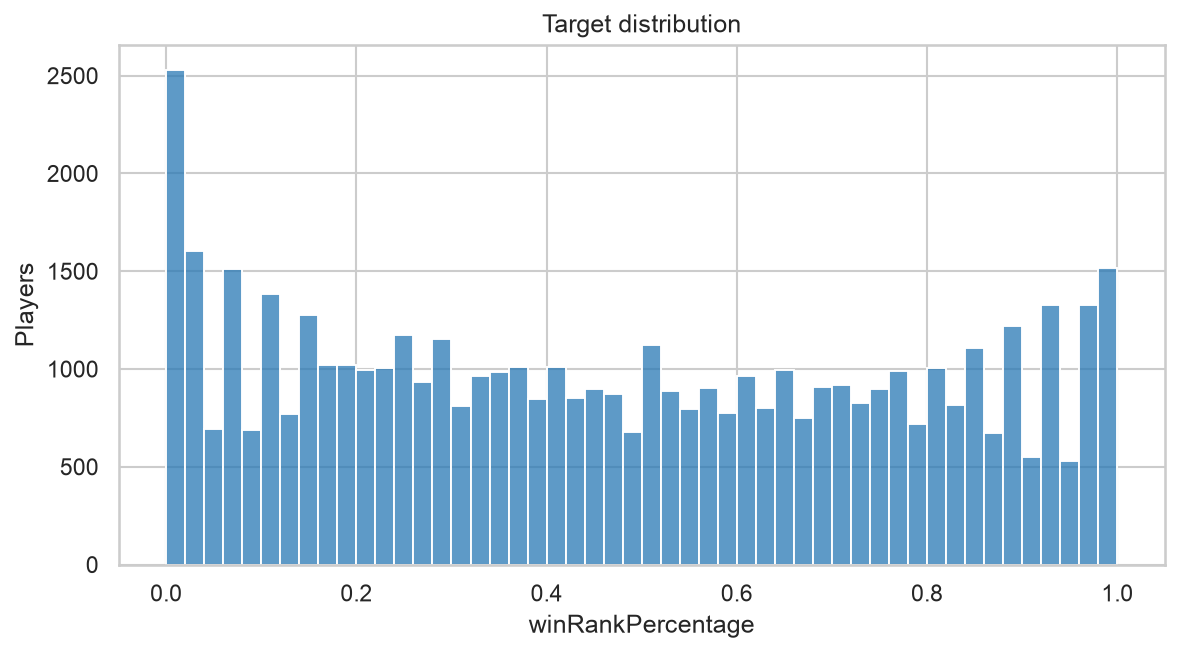

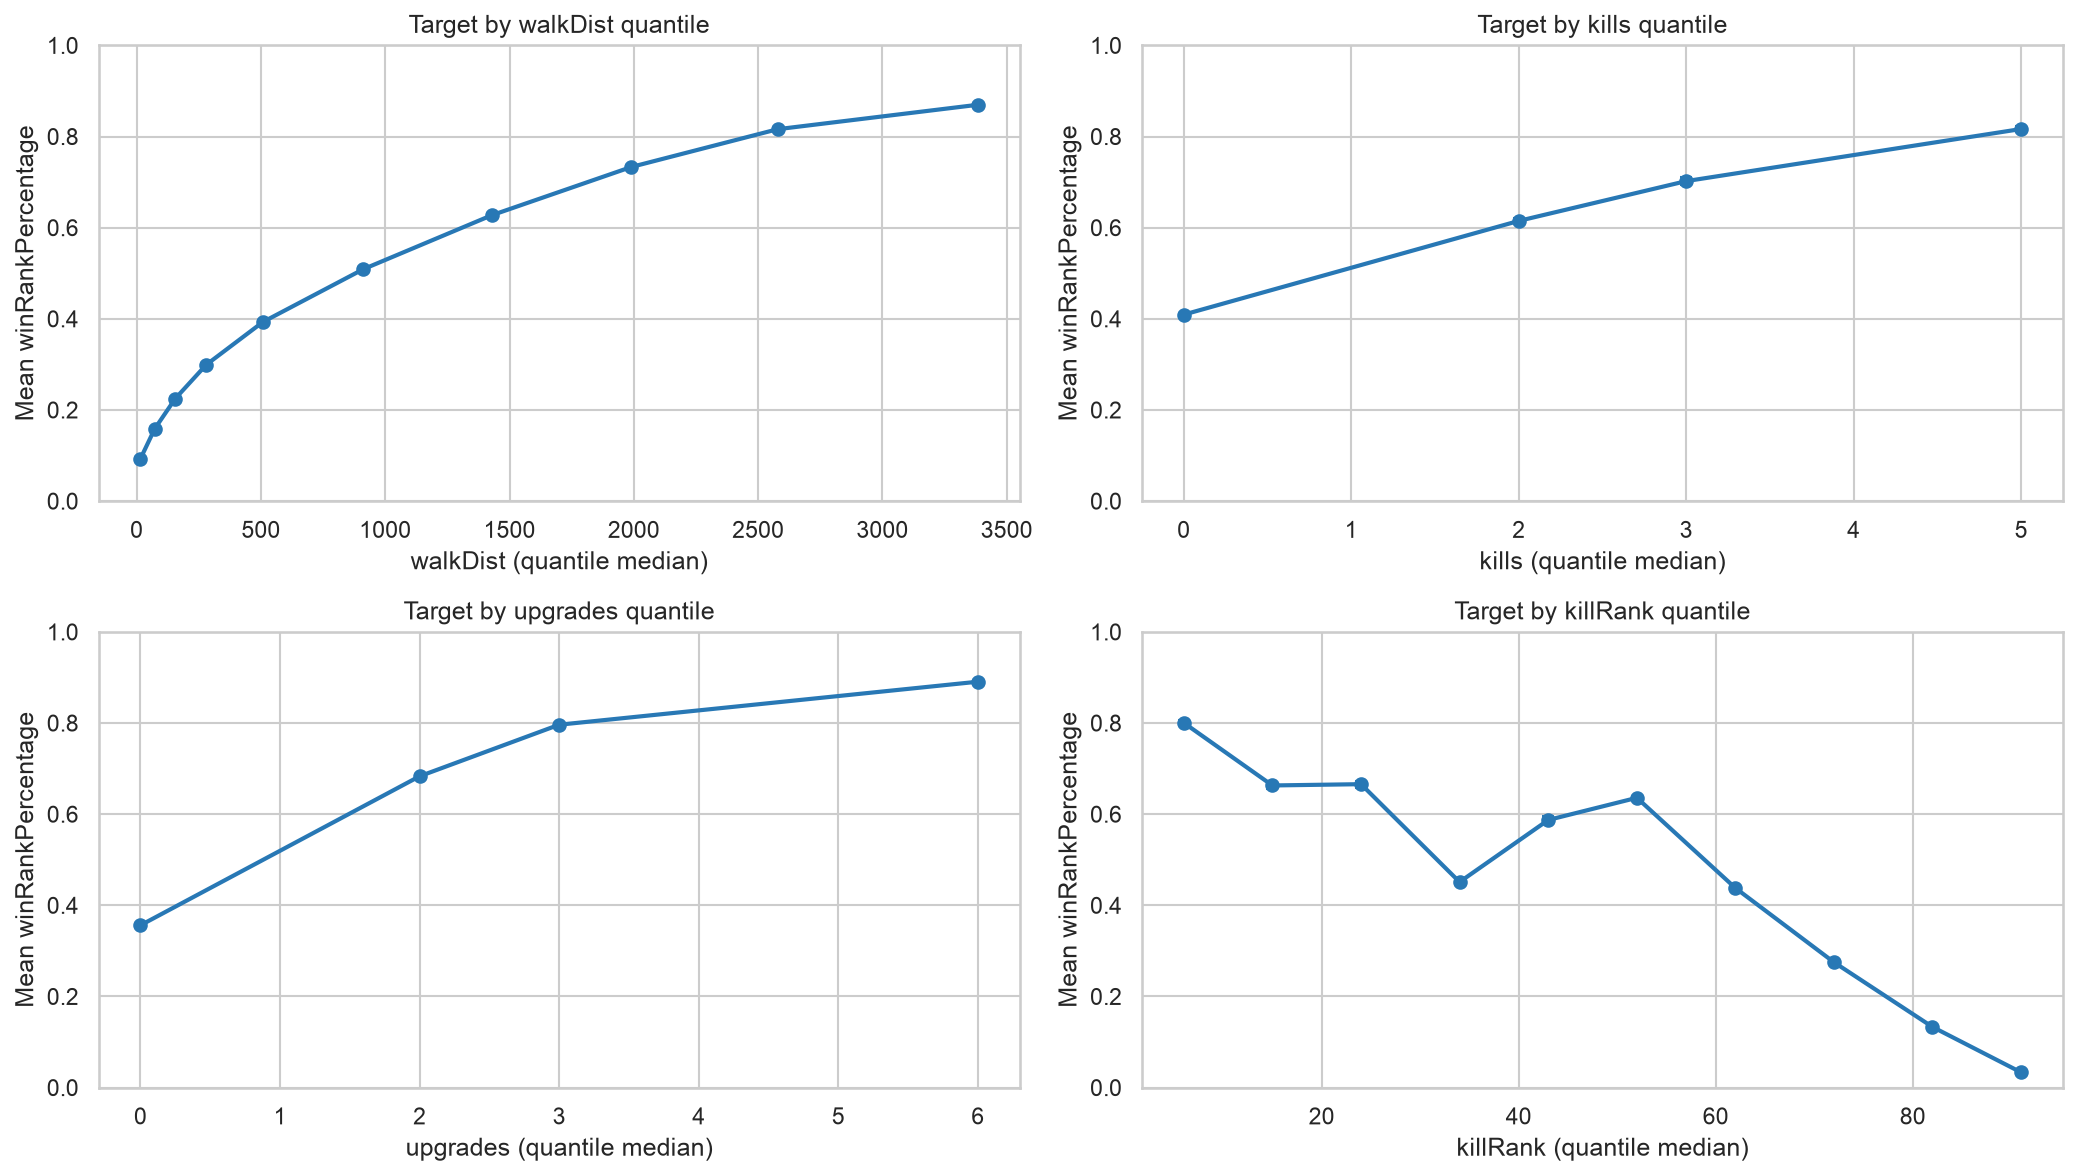

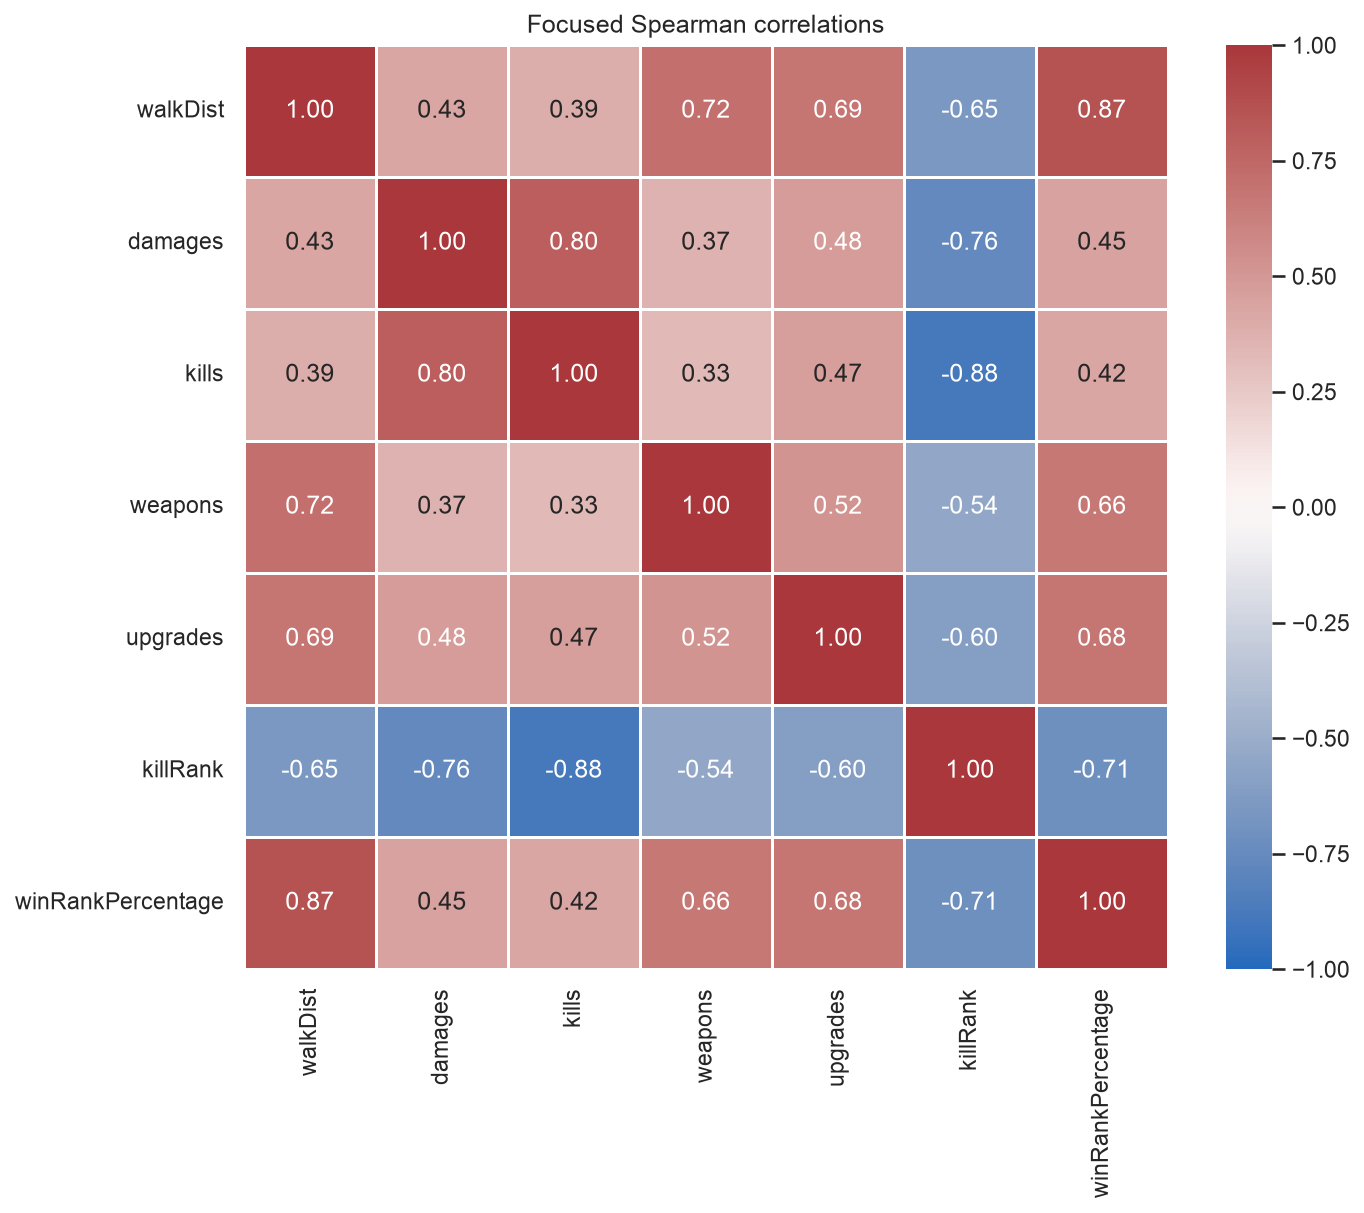

In [8]:
display(tables["target_grid"].to_frame("value"))
display(tables["numeric_profile"])
display(Image(filename=str(results["paths"]["figure_target"])))
display(Image(filename=str(results["paths"]["figure_profiles"])))
display(Image(filename=str(results["paths"]["figure_correlations"])))

I examine four hypotheses: (1) mobility strongly reflects match progression;
(2) combat and resources add behavioural information; (3) `killRank`, already
computed after the match, should dominate the post-match scenario; and (4)
modes change the scale of behaviours. Quantile profiles and their 95% intervals
show nonlinear relationships, while I keep the Spearman matrix focused so those
effects remain visible.

## 7. Analytical KPIs

In [9]:
display(tables["kpi_evaluation"])

,kpi,formula,defined_pct,mean,median,p95,zero_pct_among_defined,spearman_target,most_redundant_source,max_abs_source_spearman,model_decision
0,total_distance,walkDist + rideDist + swimDist,100.000000,"1,761.907329",792.000000,"6,430.050000",2.136000,0.832147,walkDist,0.943067,analytic_only_redundant
1,mobility_per_match_second,total_distance / gameTime,100.000000,1.074005,0.510672,3.519943,2.136000,0.848123,total_distance,0.994194,analytic_only_match_time_not_survival
2,damage_per_kill_kpi,damages / kills; 0 when kills=0,100.000000,53.572314,0.000000,190.600000,57.072000,0.369443,kills,0.890303,candidate_requires_ablation
3,headshot_ratio,headshots / kills; undefined when kills=0,43.034000,0.236041,0.000000,1.000000,61.026165,0.106378,headshots,0.942995,analytic_only_sparse
4,combat_activity_kpi,kills + assists + knocks,100.000000,1.809560,1.000000,7.000000,45.468000,0.429753,kills,0.900159,candidate_requires_ablation
5,resource_activity_kpi,weapons + upgrades + heals,100.000000,6.145900,5.000000,17.000000,5.078000,0.771366,weapons,0.861983,candidate_requires_ablation
6,support_actions,assists + revives,100.000000,0.396940,0.000000,2.000000,74.168000,0.363548,assists,0.794826,analytic_only_mode_dependent


I define an explicit rule for every zero denominator. I keep `total_distance`,
mobility per second, and headshot ratio descriptive because they are redundant,
use `gameTime` rather than survival time, or are too sparse. I include
`damage_per_kill`, `combat_activity`, and `resource_activity` in the ablation:
I retain them only when they show measured value, not because they sound
plausible.

## 8. Features and progressive ablation

,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting,mae_gain_vs_previous
stage,,,,,,,,,,,,,,,,
1. context,1. context,0.267714,0.000952,0.266690,0.269146,0.307390,0.001036,-0.000213,0.001589,0.266685,0.001029,19.983305,0.037272,4,small gap,NaN
2. + mobility,2. + mobility,0.098414,0.000535,0.097895,0.099322,0.134965,0.001694,0.807144,0.005261,0.093079,0.005335,35.129280,0.055531,7,moderate gap,0.169300
3. + combat,3. + combat,0.095515,0.000438,0.095236,0.096281,0.131921,0.001526,0.815748,0.004791,0.088753,0.006762,33.913193,0.134661,11,moderate gap,0.002899
4. + resources,4. + resources,0.092661,0.000665,0.092060,0.093755,0.129242,0.001801,0.823144,0.005416,0.085183,0.007478,30.518253,0.051237,15,moderate gap,0.002854
5. + killRank post-match,5. + killRank post-match,0.061500,0.001126,0.060768,0.063369,0.086609,0.001917,0.920562,0.003629,0.055258,0.006243,33.610205,0.051410,16,moderate gap,0.031161


,mae,rmse,r2,features
scenario,,,,
post_match_with_killRank,0.061448,0.086477,0.920845,16
behavior_without_killRank,0.092661,0.129242,0.823144,15
post_match_grid_snapped,0.060982,0.086882,0.920102,16


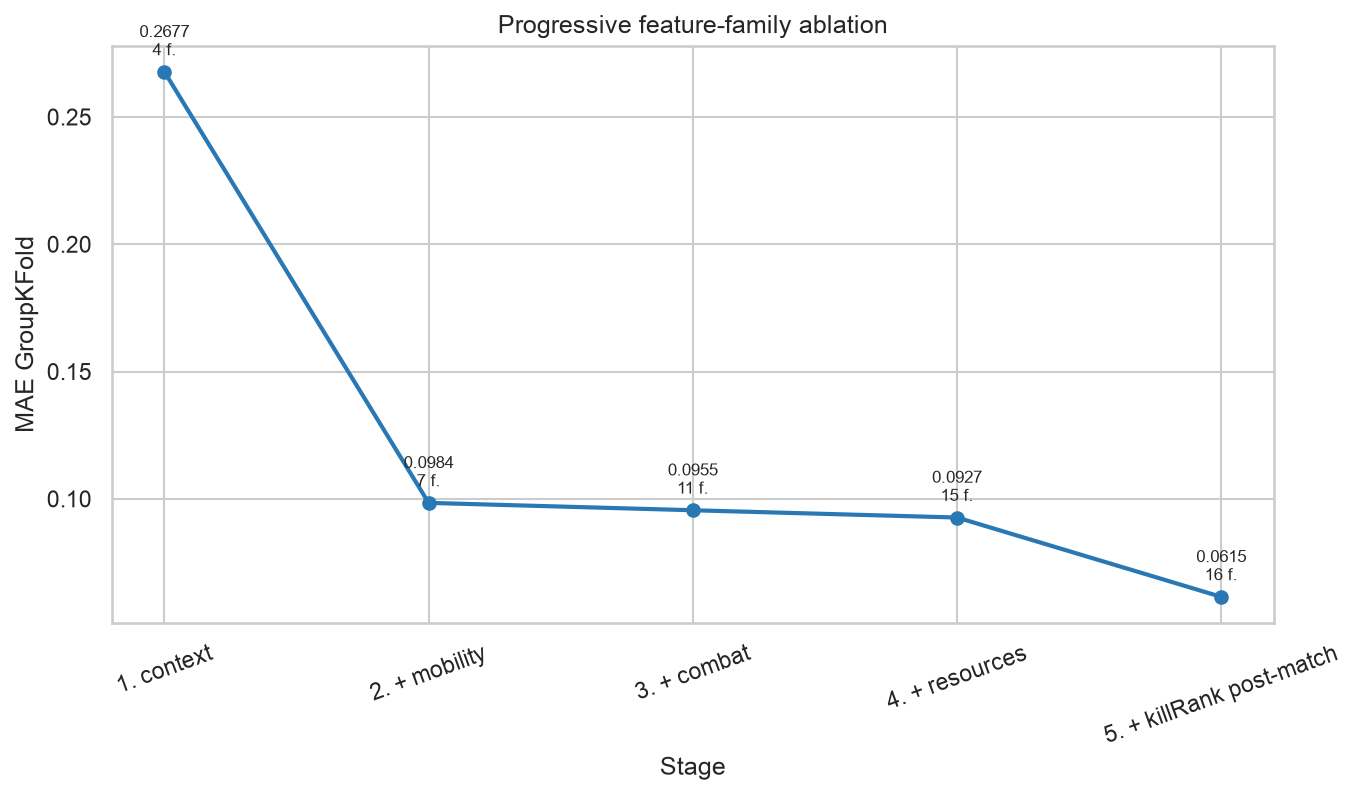

In [10]:
display(tables["feature_ablation"].set_index("stage"))
display(tables["scenario_comparison"].set_index("scenario"))
display(Image(filename=str(results["paths"]["figure_ablation"])))

Mobility produces my main behavioural gain; combat and resources then improve
MAE modestly. Adding `killRank` reduces MAE from about 0.0927 to 0.0615, so I
explicitly describe the published model as **post-match**, not as early-game
prediction. Snapping to the `maxRank` grid improves MAE slightly but worsens
RMSE; I reserve it for the submission and document that trade-off.

## 9. Validation and leakage checks

,fold,train_rows,validation_rows,shared_groups,shared_raw_game_ids,invalid_train_rows,invalid_validation_rows
0,1,32102,8026,0,0,59,17
1,2,32102,8026,0,0,59,17
2,3,32102,8026,0,0,62,14
3,4,32103,8025,0,0,62,14
4,5,32103,8025,0,0,62,14


,strategy,train_rows,validation_rows,shared_groups,shared_raw_game_ids,validation_rows_from_seen_games_pct,train_date_min,train_date_max,validation_date_min,validation_date_max
0,Random row,40000,10000,5114,5114,56.640000,2024-01-01,2024-04-30 00:00:00.000000000,2024-01-01 00:13:42.544450889,2024-04-29 23:36:00.547210944
1,Grouped gameId,39901,10099,0,0,0.000000,2024-01-01,2024-04-29 23:56:34.363887278,2024-01-01 00:10:16.908338166,2024-04-30 00:00:00.000000000
2,Naive Jan-Mar → Apr,37815,12185,5908,5908,54.969224,2024-01-01,2024-03-31 23:58:43.966479330,2024-04-01 00:02:09.602592052,2024-04-30 00:00:00.000000000
3,Purged Jan-Mar → Apr,29279,12185,0,0,0.000000,2024-01-01,2024-03-31 23:58:43.966479330,2024-04-01 00:02:09.602592052,2024-04-30 00:00:00.000000000


,strategy,train_rows,validation_rows,train_mae,mae,rmse,r2,fit_seconds,predict_seconds
0,Random row,40000,10000,0.055854,0.060949,0.085371,0.923908,5.835309,0.016013
1,Grouped gameId,39901,10099,0.055730,0.061160,0.085936,0.921702,6.093661,0.016845
2,Naive Jan-Mar → Apr,37815,12185,0.055663,0.060944,0.085253,0.923750,6.135946,0.028532
3,Purged Jan-Mar → Apr,29279,12185,0.054965,0.061277,0.085688,0.922970,4.408568,0.013769


,strategy,train_rows,validation_rows,shared_groups,shared_raw_game_ids,validation_rows_from_seen_games_pct,train_date_min,train_date_max,validation_date_min,validation_date_max
0,Final cycle holdout,40128,9872,0,0,0.000000,2024-01-01,2024-04-30,2024-01-01 00:03:25.636112722,2024-04-29 23:42:51.819436390


,model,development_rows,holdout_rows,train_mae,mae,rmse,r2,mae_gap,fit_seconds,predict_seconds,shared_games,decision_frozen_before_holdout,historical_limitation
0,CatBoost,40128,9872,0.055770,0.060797,0.086596,0.920827,0.005027,9.415954,0.015535,0,True,"independent of this audit cycle, but earlier E..."


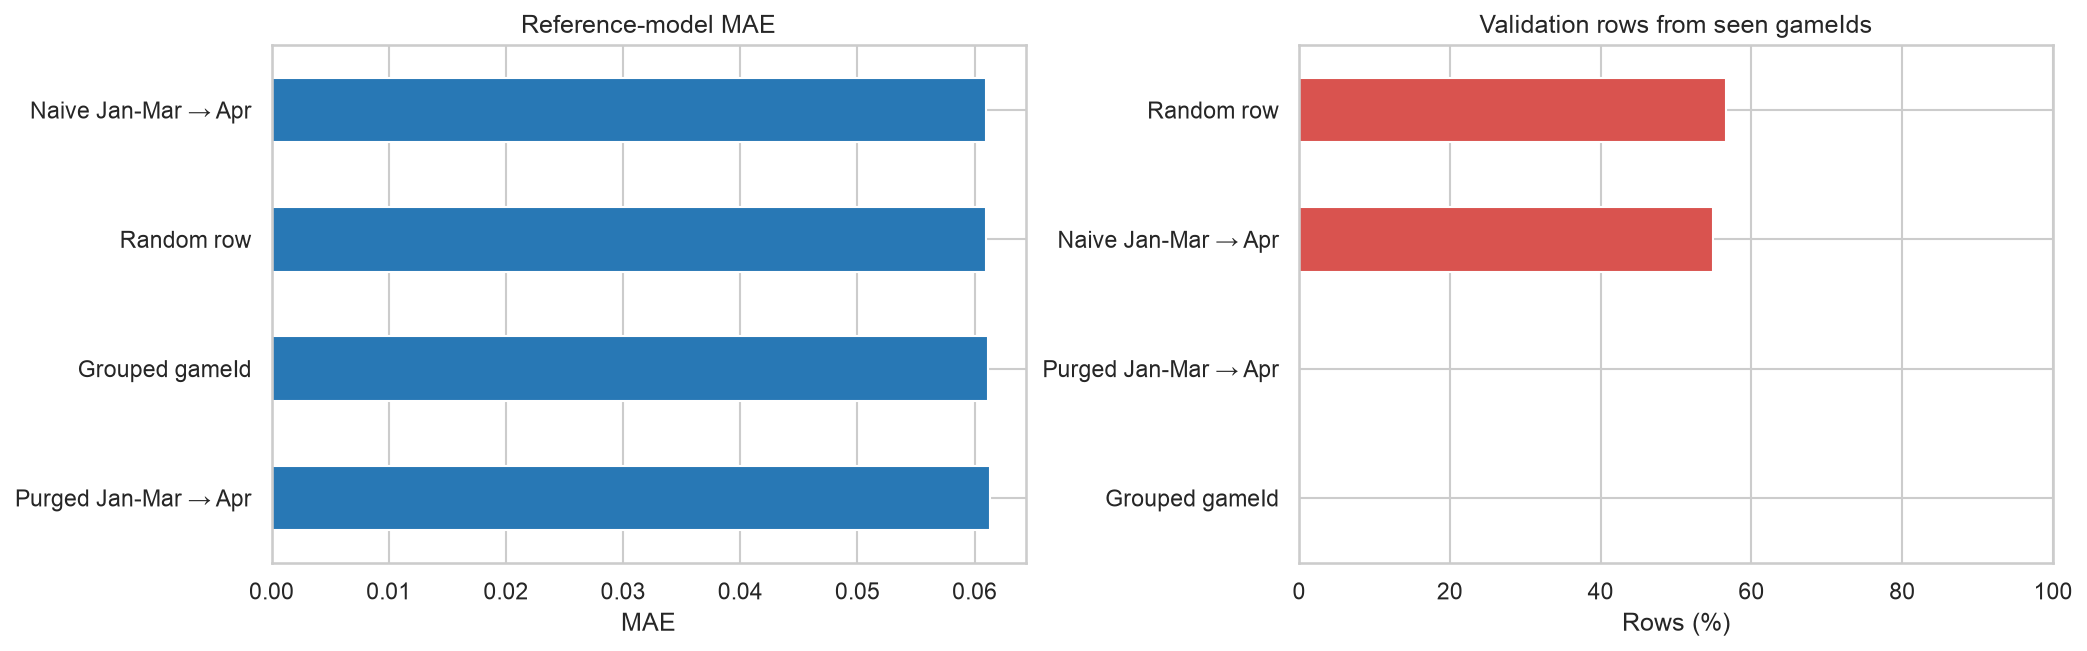

In [11]:
display(tables["fold_audit"])
display(tables["holdout_audit"])
display(tables["holdout_performance"])
display(tables["final_holdout_audit"])
display(tables["final_holdout_evaluation"])
display(Image(filename=str(results["paths"]["figure_validation"])))

I freeze a grouped holdout before model selection. The remaining 40,128 rows
feed 5-fold GroupKFold; I group repeated malformed values conservatively and no
identifier crosses a partition. A row-random split exposes more than half of its
validation rows to already seen matches. The January–March → April stress test
remains non-chronological because `date` is inconsistent. After freezing the
decision, CatBoost reaches about 0.06080 MAE on the cycle's 9,872-row holdout.

## 10. Selecting the number of folds

,CatBoost,XGBoost,mae_std,mae_standard_error,mean_validation_rows,catboost_winning_folds,fit_cost_relative_to_5_folds
n_splits,,,,,,,
3,0.061564,0.063748,0.000698,0.000403,"13,376.000000",3,0.830010
5,0.061448,0.063448,0.001095,0.000490,"8,025.600000",5,1.000000
7,0.061260,0.063488,0.000873,0.000330,"5,732.571429",7,0.833661
10,0.061368,0.063318,0.001354,0.000428,"4,012.800000",10,2.416198


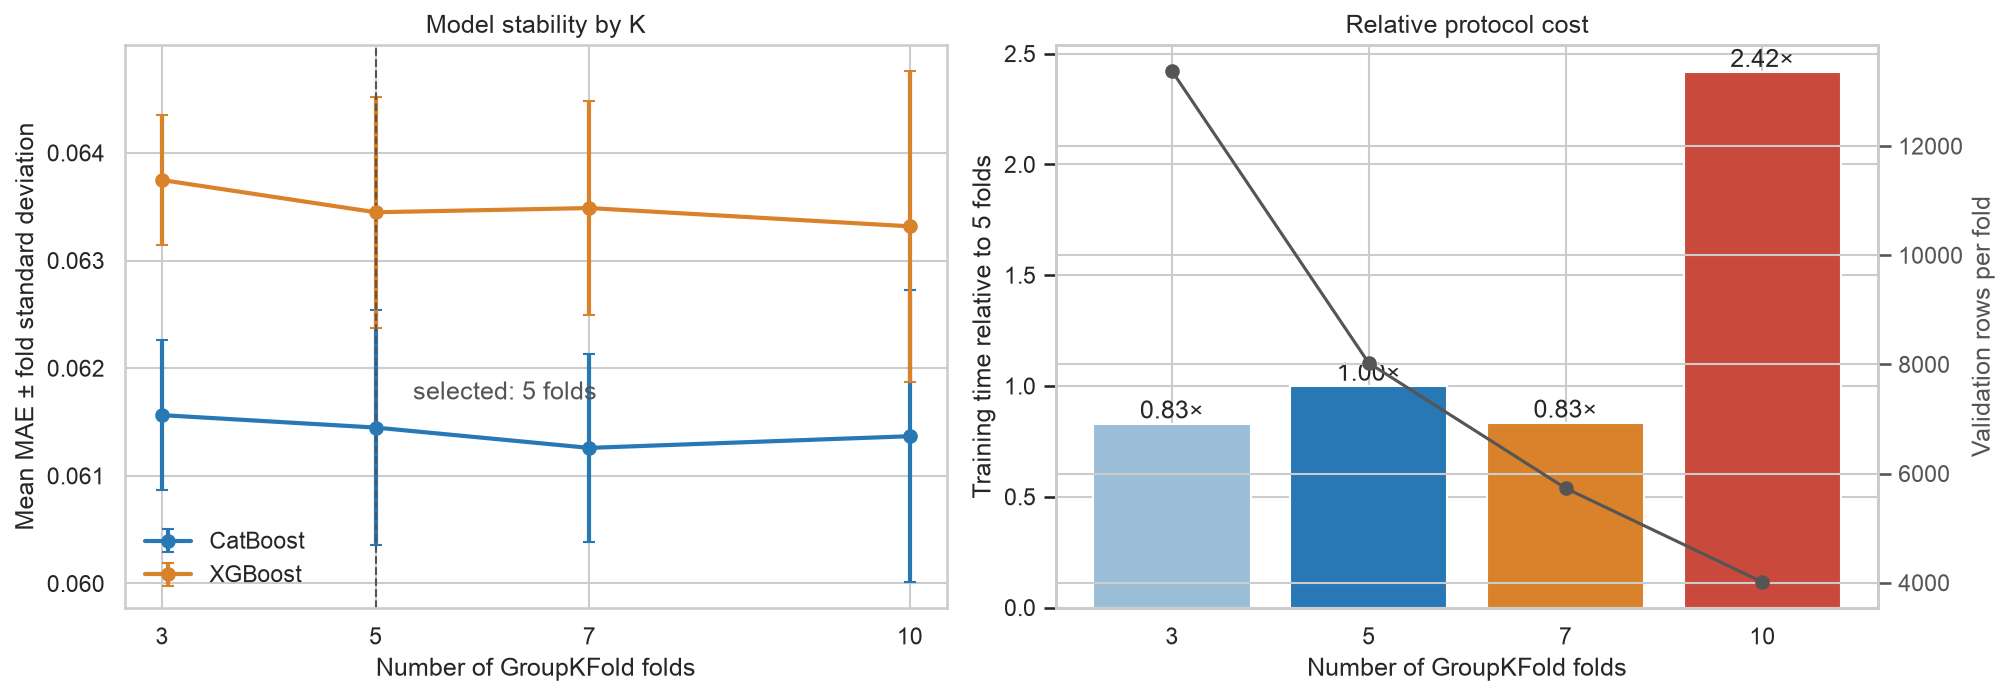

In [12]:
fold_metrics_path = PROJECT_ROOT / "artifacts" / "metrics" / "fold_count_sensitivity.csv"
fold_decision_path = PROJECT_ROOT / "artifacts" / "metrics" / "fold_count_decision.csv"
fold_figure_path = PROJECT_ROOT / "artifacts" / "figures" / "07c_fold_count_sensitivity.png"
if not (fold_metrics_path.exists() and fold_decision_path.exists() and fold_figure_path.exists()):
    from scripts.run_fold_count_study import main as run_fold_count_study

    run_fold_count_study()

fold_sensitivity = pd.read_csv(fold_metrics_path)
fold_decision = pd.read_csv(fold_decision_path)
fold_comparison = (
    fold_sensitivity.pivot(index="n_splits", columns="model", values="mae")
    .join(fold_sensitivity.loc[fold_sensitivity["model"].eq("CatBoost")].set_index("n_splits")[
        ["mae_std", "mae_standard_error", "mean_validation_rows"]
    ])
    .join(fold_decision.set_index("n_splits")[
        ["catboost_winning_folds", "fit_cost_relative_to_5_folds"]
    ])
)
display(fold_comparison)
display(Image(filename=str(fold_figure_path)))

I compare `GroupKFold` with K=3, 5, 7, and 10 on the same 40,128 development
rows while keeping the final holdout closed. CatBoost beats XGBoost in all 25
combined folds. Seven folds reports a nominally lower MAE than five (a
**0.000189** gain), but that gap is below the folds' standard error and also
comes from mechanically larger training sets.

**My decision: 5 folds.** Each validation set retains about 8,026 independent
match rows, the CatBoost choice is already stable in all five folds, and seven
folds add meaningful computational cost. Ten folds at least doubles the
measured cost, reduces validation to about 4,013 rows, and increases dispersion.
The exact time ratio depends on the machine and is shown in the figure. Choosing
K=7 solely because its displayed score is lowest would optimize the protocol
after seeing results.

## 11. Baselines and initial comparison

,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting
rank,,,,,,,,,,,,,,,
1,CatBoost,0.061448,0.001095,0.060766,0.063341,0.086460,0.001895,0.920835,0.003616,0.055269,0.006180,54.148810,0.074884,16,moderate gap
2,XGBoost,0.063448,0.001073,0.062617,0.065308,0.089602,0.001737,0.914989,0.003288,0.050440,0.013009,3.894502,0.094206,16,large gap
3,LightGBM,0.063593,0.000912,0.063063,0.065216,0.089087,0.001427,0.915970,0.002741,0.059488,0.004105,7.908350,0.197214,16,moderate gap
4,Random Forest,0.066677,0.000771,0.066054,0.068012,0.094343,0.001460,0.905764,0.002954,0.024722,0.041955,36.793972,0.457518,16,large gap
5,Linear Ridge baseline,0.088310,0.001395,0.086679,0.090082,0.122248,0.001965,0.841775,0.004876,0.088256,0.000054,0.137757,0.017058,16,small gap
6,Median baseline,0.267877,0.000822,0.267188,0.269101,0.307808,0.001005,-0.002935,0.001421,0.267862,0.000016,0.000000,0.000000,16,non applicable
7,Mean baseline,0.268151,0.000792,0.267432,0.269250,0.307374,0.000920,-0.000112,0.000142,0.268143,0.000008,0.000000,0.000000,16,non applicable


,reference_model,candidate_model,folds,mean_mae_difference,ci95_lower,ci95_upper,candidate_worse_folds
0,CatBoost,XGBoost,5,0.002000,0.001829,0.002192,5
1,CatBoost,LightGBM,5,0.002144,0.001920,0.002369,5
2,CatBoost,Random Forest,5,0.005229,0.004917,0.005513,5
3,CatBoost,Linear Ridge baseline,5,0.026862,0.026301,0.027506,5
4,CatBoost,Median baseline,5,0.206429,0.205216,0.207402,5
5,CatBoost,Mean baseline,5,0.206703,0.205360,0.207708,5


,Unnamed: 0,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting
0,1,XGBoost pre-audit custom,0.061999,0.001053,0.061296,0.063836,0.087360,0.001885,0.919182,0.003562,0.051368,0.010631,22.727725,0.287247,16,moderate gap
1,0,CatBoost pre-audit custom,0.062053,0.001187,0.061221,0.063976,0.087117,0.001894,0.919629,0.003612,0.058519,0.003533,71.115309,0.093738,16,moderate gap


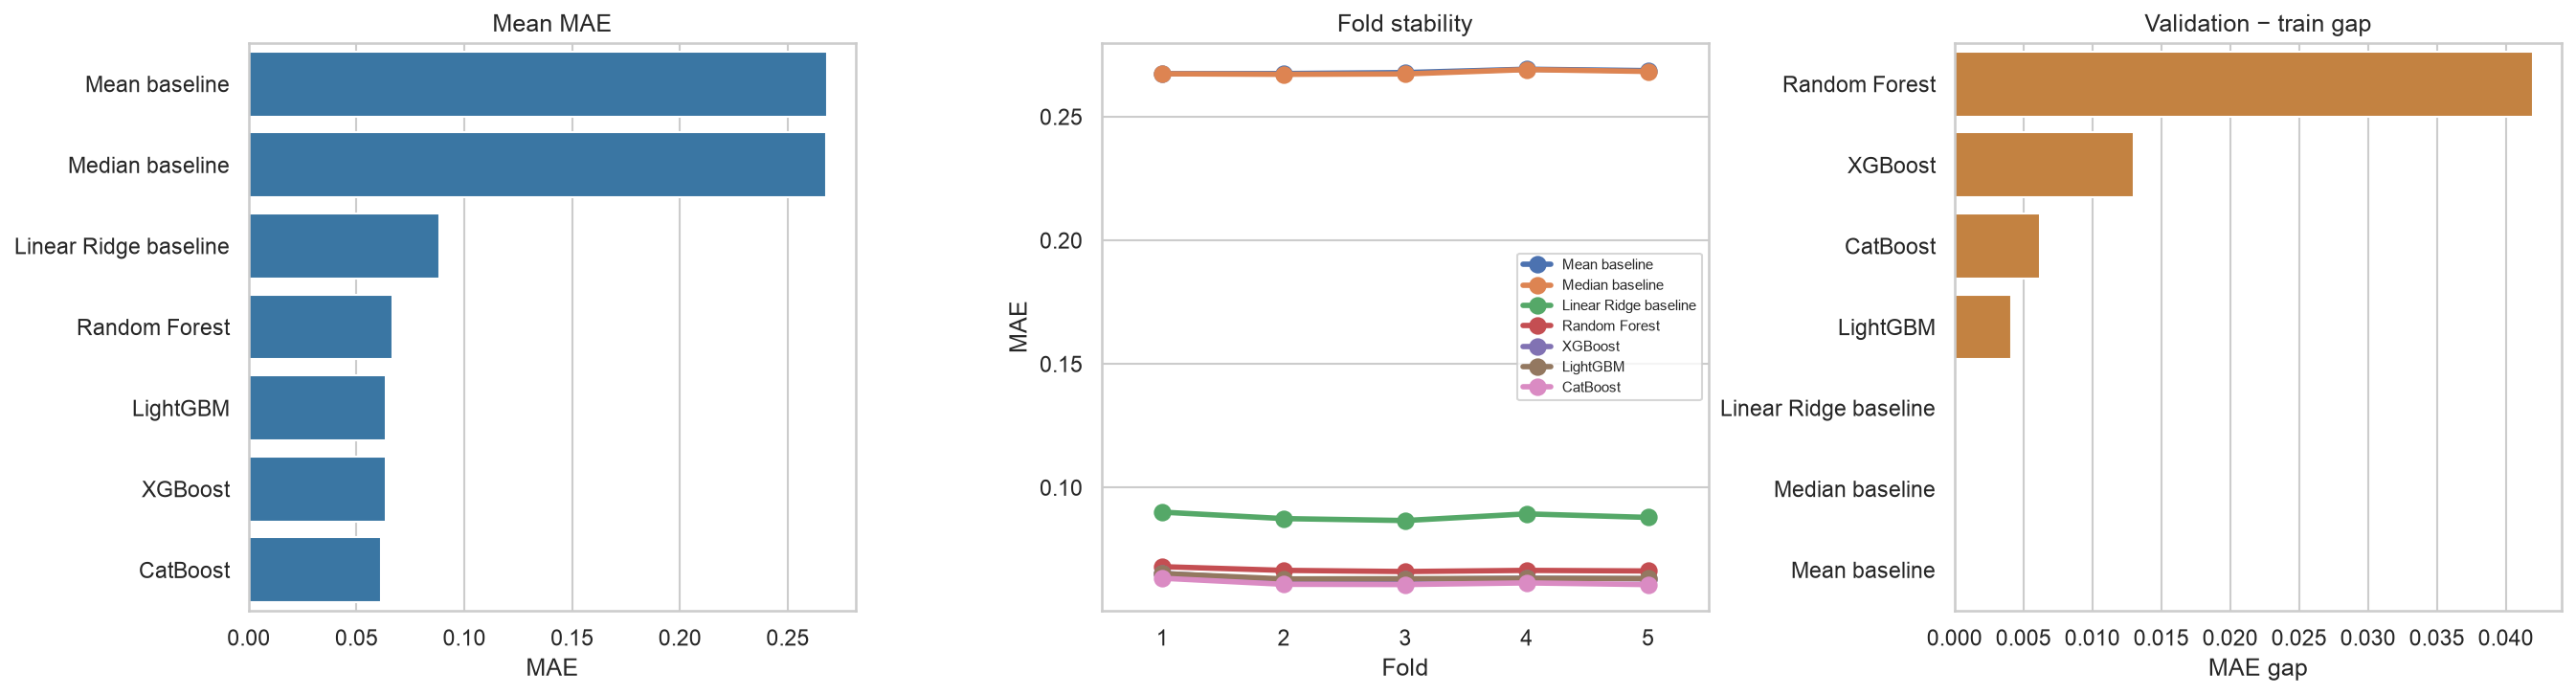

In [13]:
display(tables["initial_model_comparison"].set_index("rank"))
display(tables["model_fold_uncertainty"])
display(tables["pre_audit_configuration_comparison"])
display(Image(filename=str(results["paths"]["figure_models"])))

I use mean/median `DummyRegressor` models and Ridge as baselines. The four
ensembles use library-default learning hyperparameters, with only the seed,
parallelism, objective, and verbosity stated explicitly. CatBoost beats XGBoost
by about 0.0020 MAE and in all five folds. Replaying the earlier customized
configurations gives XGBoost only a 0.000054 advantage; that pre-tuning explains
the historical reversal of the winner.

## 12. Bounded tuning and anti-overfitting decision

,trial,random_strength,learning_rate,l2_leaf_reg,iterations,depth,border_count,mae,mae_std,train_mae,fit_seconds,predict_seconds,mae_gap
0,1,2.000000,0.050000,10.000000,1200,6,254,0.061671,0.001093,0.057417,9.873878,0.018842,0.004254
1,2,1.000000,0.080000,10.000000,1200,4,64,0.062444,0.001097,0.059170,5.693021,0.015415,0.003274
2,3,0.500000,0.030000,5.000000,800,8,64,0.062522,0.000940,0.058681,7.244573,0.013725,0.003840
3,4,1.000000,0.080000,3.000000,800,4,254,0.062679,0.001089,0.059754,3.712594,0.009612,0.002925
4,5,0.500000,0.050000,10.000000,1200,4,64,0.063085,0.001089,0.060836,9.491919,0.018789,0.002249
5,6,2.000000,0.080000,10.000000,800,4,64,0.063151,0.001083,0.060768,4.328464,0.009699,0.002383
6,7,0.500000,0.050000,1.000000,400,6,128,0.063650,0.000976,0.061304,3.472604,0.011383,0.002346
7,8,2.000000,0.030000,5.000000,400,4,64,0.070937,0.001088,0.070368,1.907029,0.006369,0.000569


,rank,model,mae,mae_std,mae_min,mae_max,rmse,rmse_std,r2,r2_std,train_mae,mae_gap,fit_seconds,predict_seconds,feature_count,overfitting,configuration
0,1.000000,CatBoost,0.061448,0.001095,0.060766,0.063341,0.086460,0.001895,0.920835,0.003616,0.055269,0.006180,54.148810,0.074884,16,moderate gap,CatBoost library defaults
1,NaN,CatBoost tuned,0.061671,0.001222,0.060792,0.063703,0.086746,0.002002,0.920308,0.003775,0.057417,0.004254,38.250891,0.060604,16,moderate gap,CatBoost randomized-search winner


,decision
accepted,False
baseline_mae,0.061448
best_parameters,"{'border_count': 254, 'depth': 6, 'iterations'..."
best_tuned_mae,0.061671
mae_gain,-0.000223
minimum_material_gain,0.000100
model_family,CatBoost


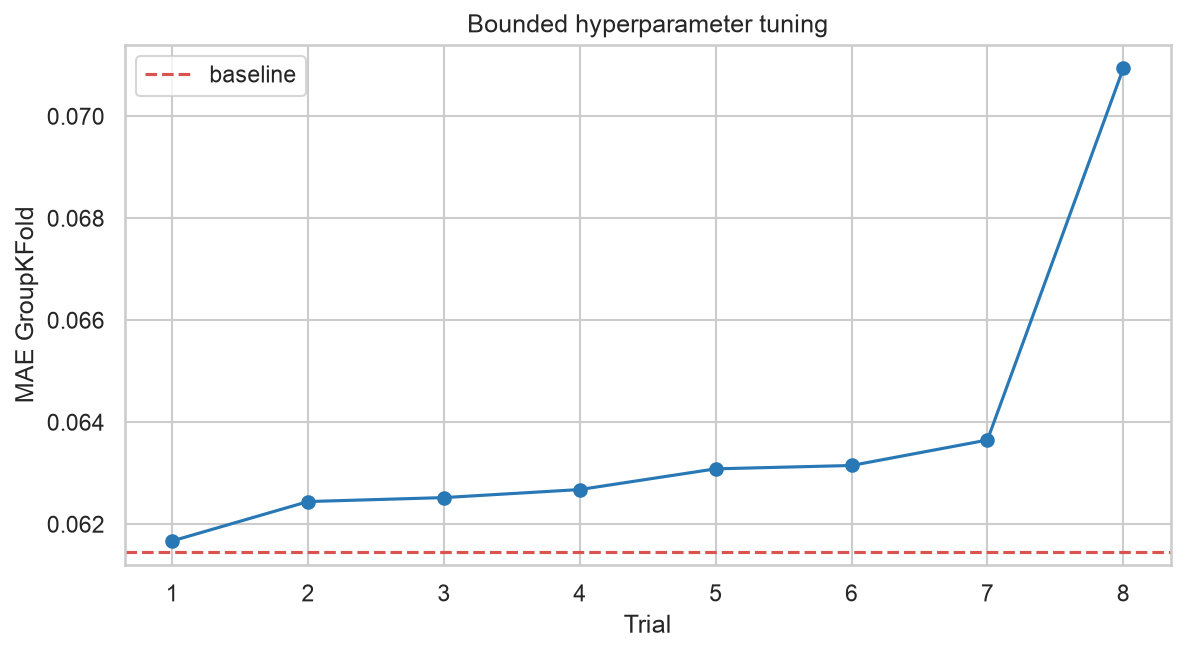

In [14]:
display(tables["tuning_trials"].sort_values("mae").head(8))
display(tables["tuning_comparison"])
display(pd.Series(results["tuning_decision"], name="decision").to_frame())
display(Image(filename=str(results["paths"]["figure_tuning"])))

I test eight CatBoost configurations with `RandomizedSearchCV` on the same
grouped folds. The best trial (0.061671) is worse than the default configuration
(0.061448) by 0.000223; it does not meet the 0.0001 material-gain threshold. I
reject tuning before opening the final holdout.

## 13. SHAP interpretability and error analysis

,feature,mae_increase_mean,mae_increase_std
0,killRank,0.281972,0.001687
1,walk_distance_per_match_minute,0.145749,0.001787
2,kills,0.096448,0.000760
3,maxRank,0.065000,0.000892
4,walkDist,0.041945,0.000559
5,mode_duo,0.018840,0.000302
6,damage_per_kill,0.014916,0.000179
7,mode_solo,0.012782,0.000340
8,mode_squad,0.008783,0.000169
9,upgrades,0.003229,0.000089


,rank,feature,mean_abs_shap,mean_shap,positive_shap_share,explained_rows,holdout_rows
0,1,killRank,0.191275,0.016444,0.584000,2000,9872
1,2,walk_distance_per_match_minute,0.111197,-0.004707,0.452000,2000,9872
2,3,kills,0.070244,-0.012982,0.598000,2000,9872
3,4,maxRank,0.054164,0.034262,0.607500,2000,9872
4,5,walkDist,0.024768,0.001993,0.523000,2000,9872
5,6,resource_activity,0.016530,0.001196,0.444500,2000,9872
6,7,upgrades,0.013954,0.000787,0.300000,2000,9872
7,8,mode_duo,0.013696,-0.013695,0.000500,2000,9872
8,9,mode_squad,0.013422,-0.009071,0.453000,2000,9872
9,10,rideDist,0.012548,0.000227,0.211500,2000,9872


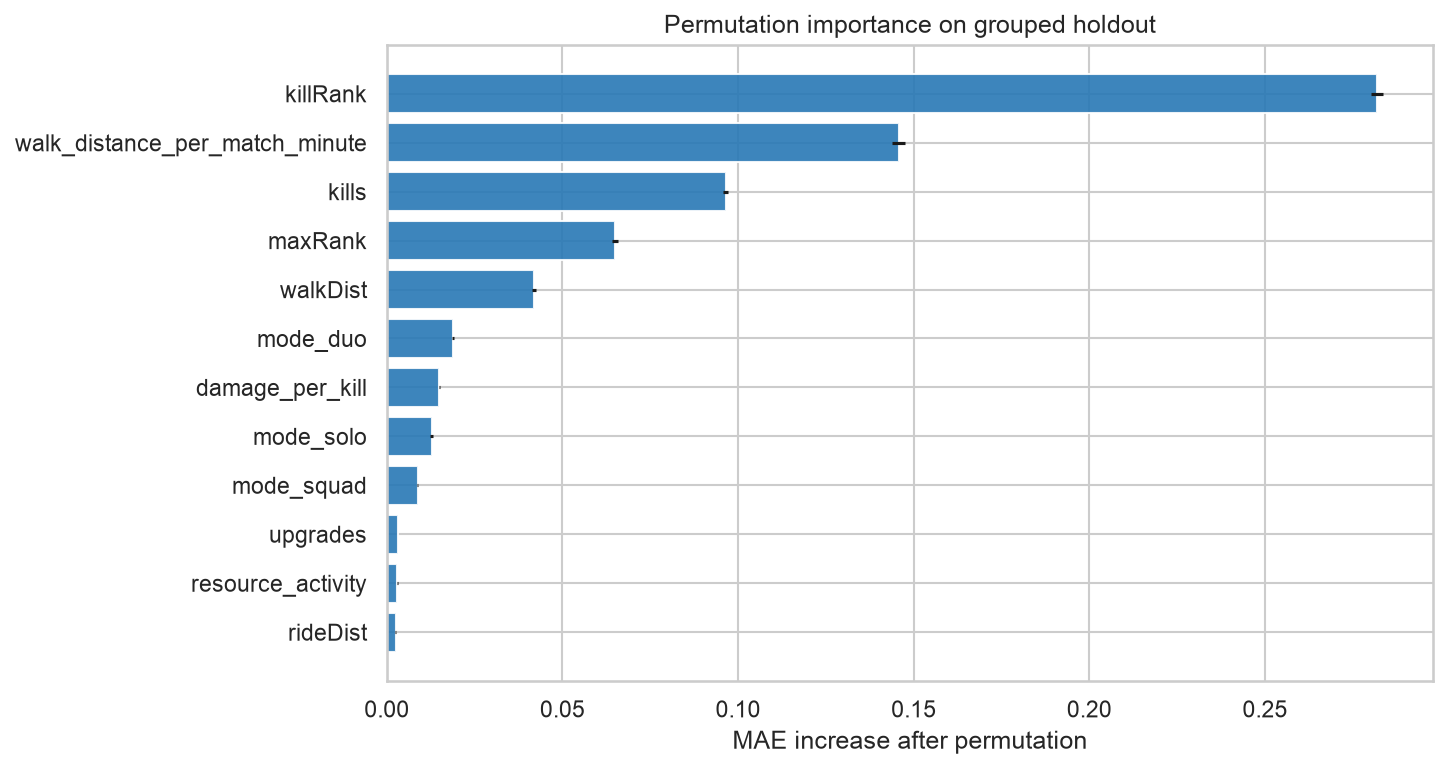

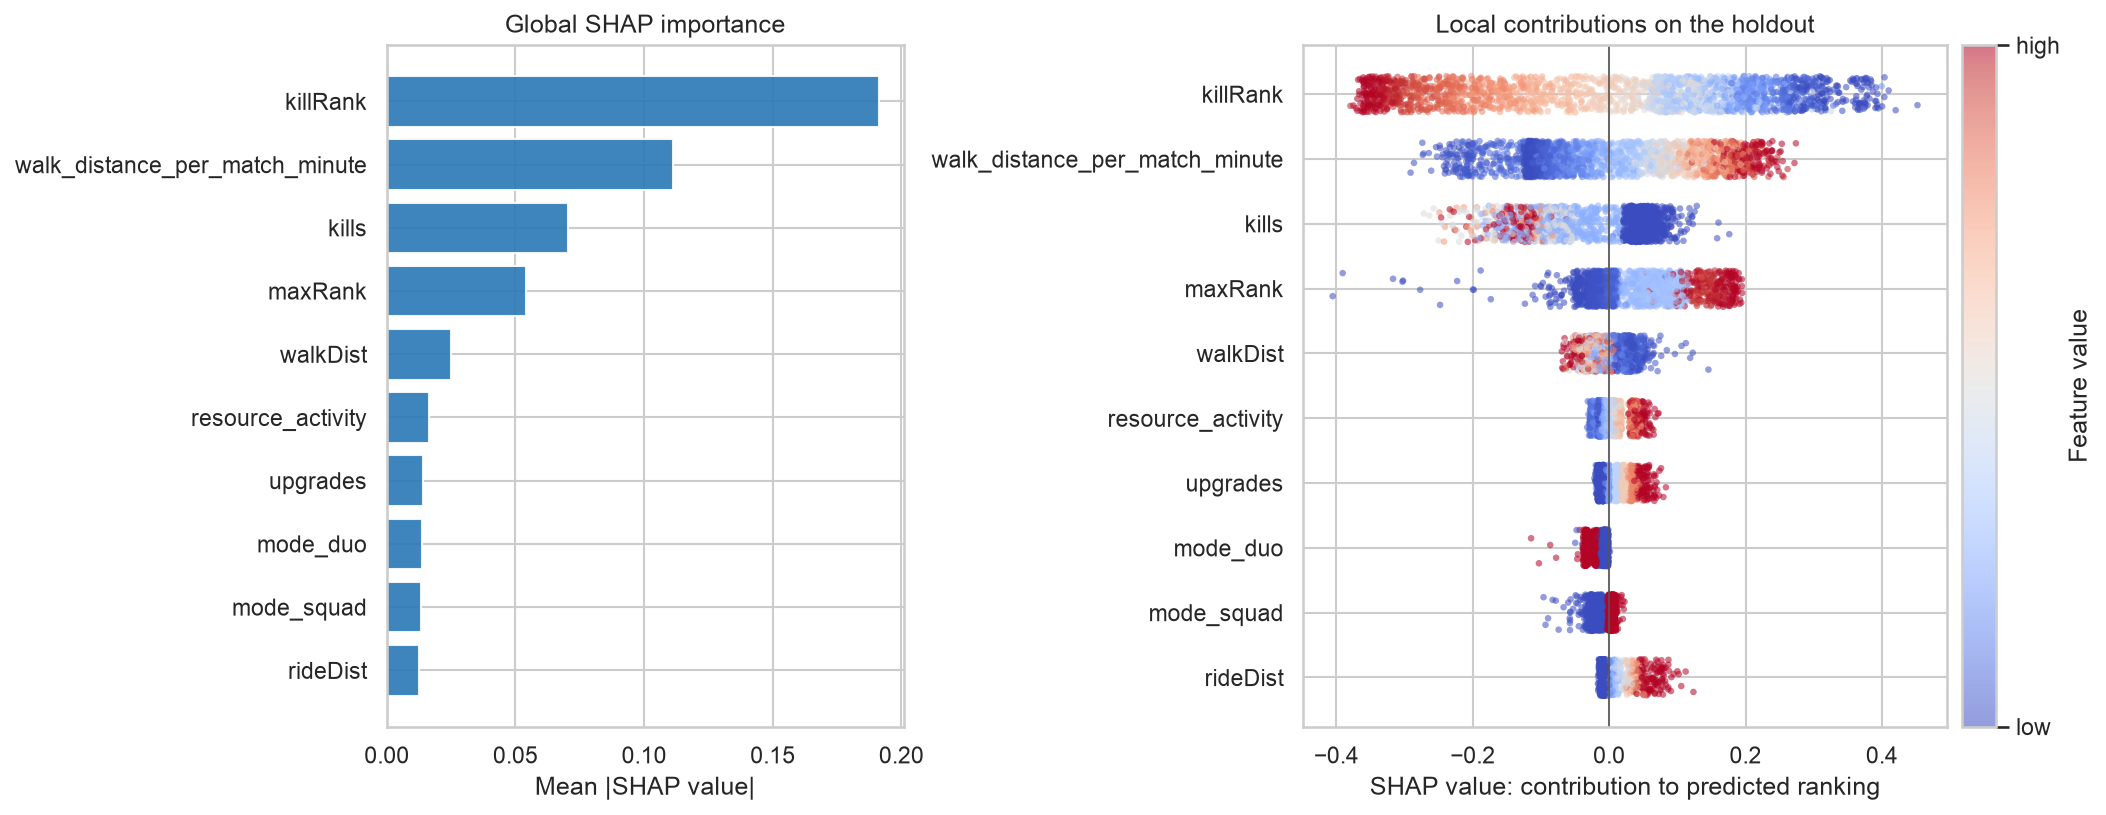

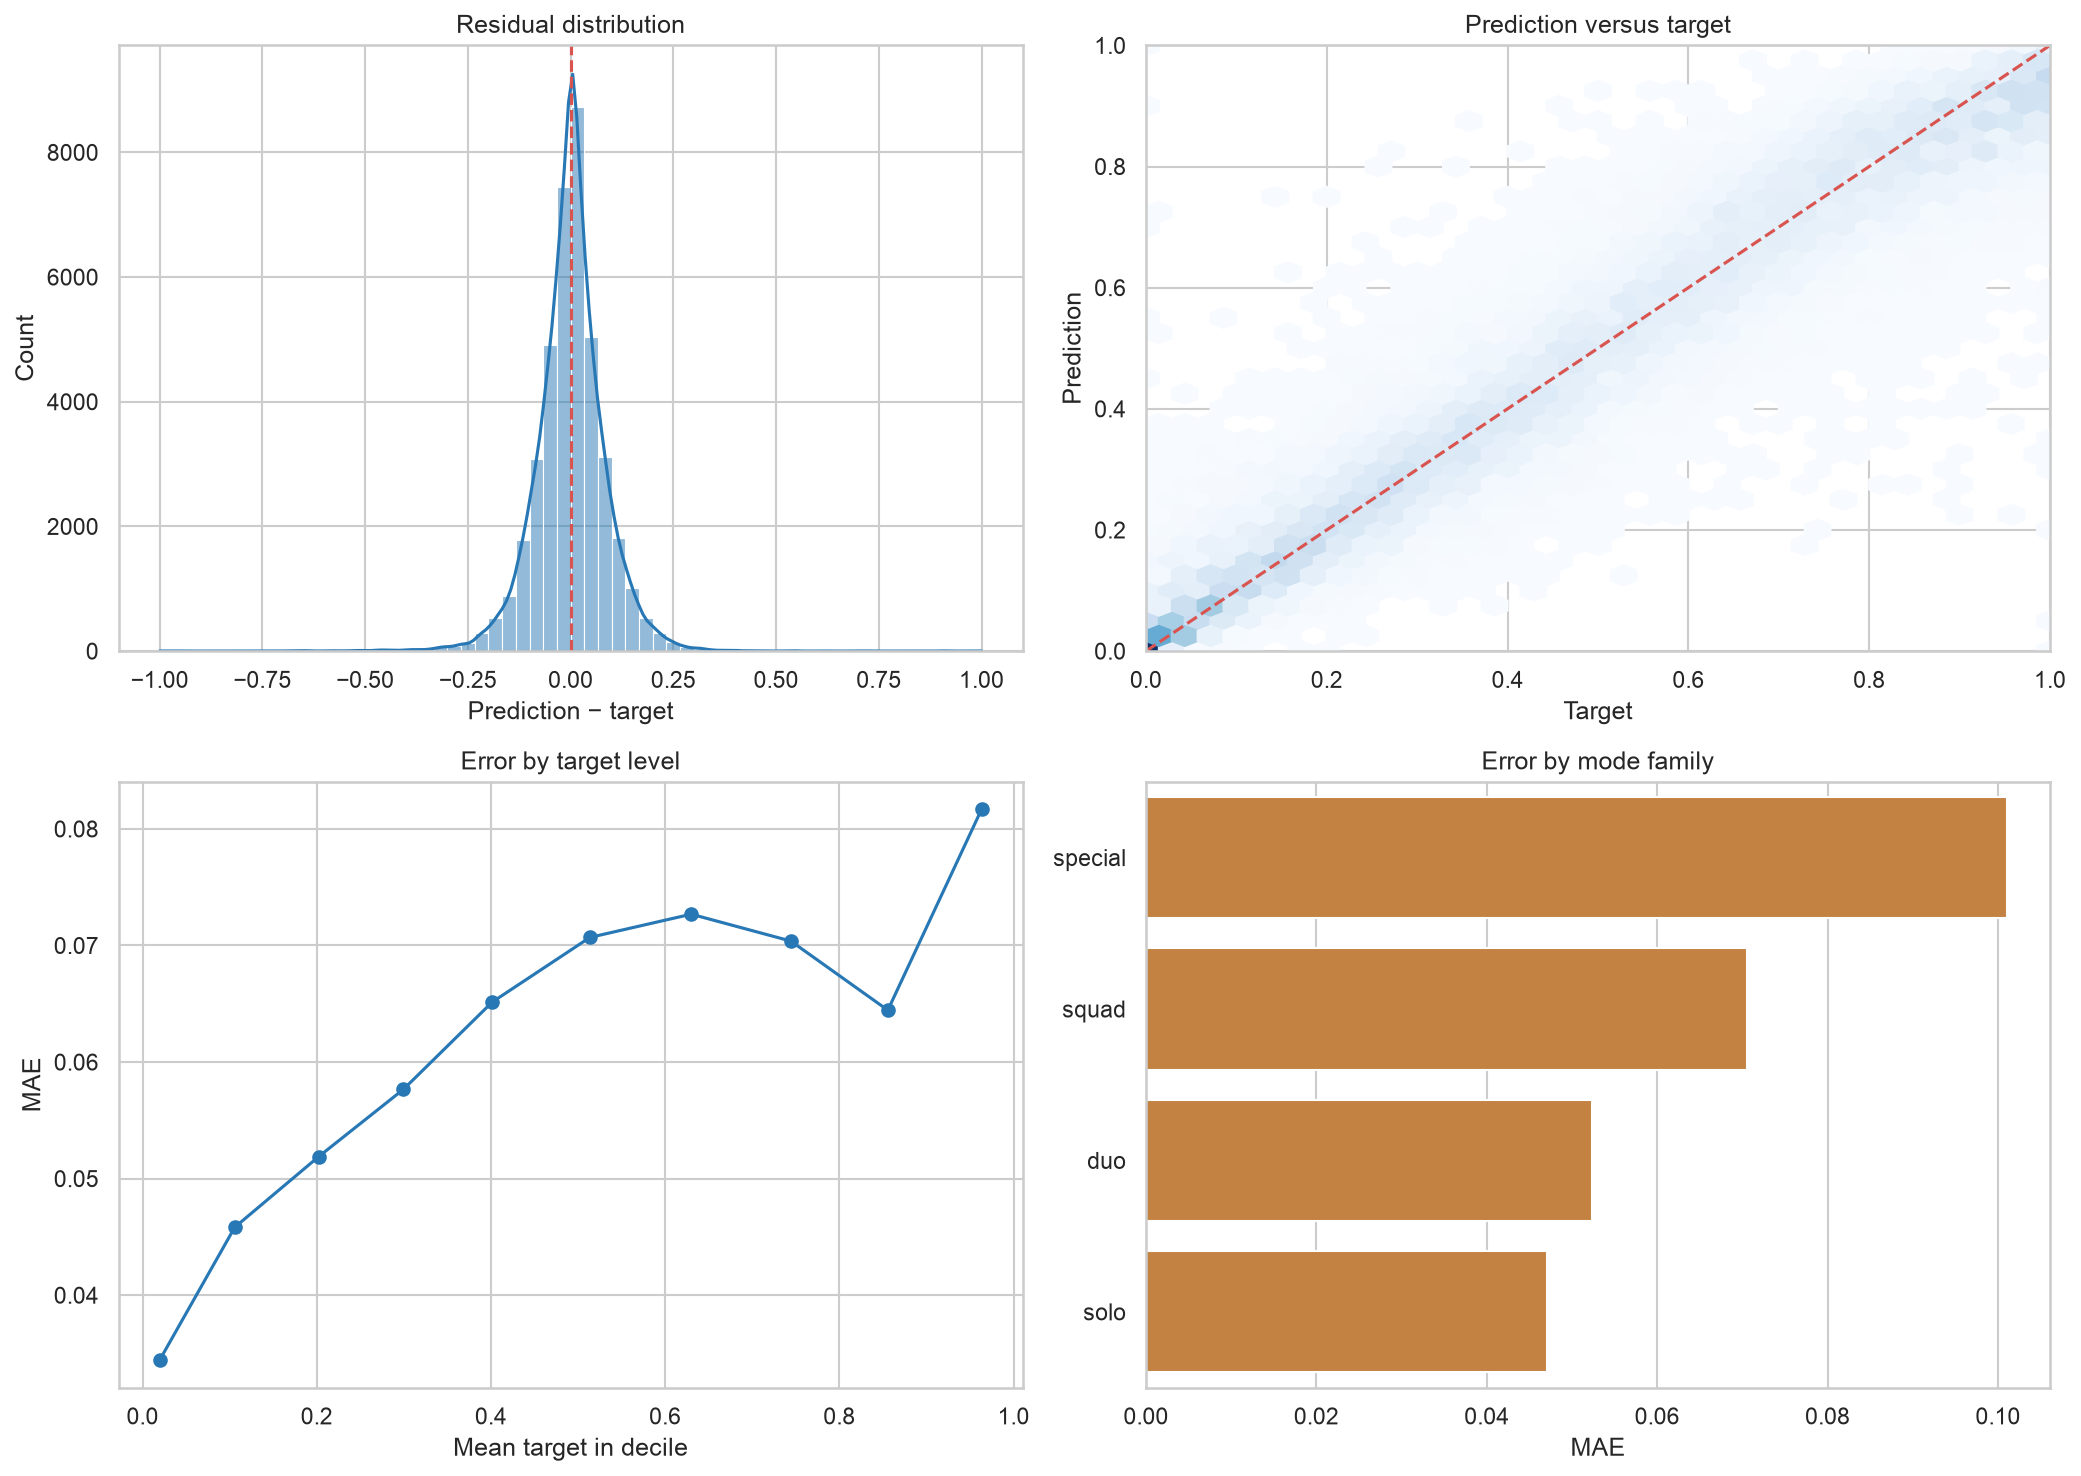

In [15]:
display(tables["permutation_importance"].head(16))
display(tables["shap_global_importance"].head(16))
display(Image(filename=str(results["paths"]["figure_importance"])))
display(Image(filename=str(results["paths"]["figure_shap"])))
display(Image(filename=str(results["paths"]["figure_errors"])))

In [16]:
important_subgroups = tables["subgroup_errors"].query(
    "dimension in ['mode_family', 'rank_grid_size', 'target_band', 'kill_band']"
)
display(important_subgroups)
display(tables["largest_errors"].head(10))

,dimension,subgroup,rows,target_mean,prediction_mean,bias,mae,rmse
0,mode_family,duo,11866,0.486204,0.486224,0.000020,0.052300,0.072228
1,mode_family,solo,6429,0.484730,0.485152,0.000422,0.047111,0.072874
2,mode_family,special,102,0.449154,0.469865,0.020711,0.101054,0.148517
3,mode_family,squad,21731,0.461461,0.461368,-0.000092,0.070500,0.096363
22,rank_grid_size,≤5,14,0.678571,0.677215,-0.001356,0.322603,0.393567
23,rank_grid_size,6–20,345,0.430793,0.434283,0.003490,0.183223,0.258874
24,rank_grid_size,21–80,33514,0.469797,0.469868,0.000070,0.063239,0.086522
25,rank_grid_size,>80,6255,0.488655,0.488577,-0.000079,0.044554,0.061827
26,target_band,0–0.1,5683,0.036334,0.066414,0.030080,0.037565,0.066164
27,target_band,0.1–0.25,6523,0.174541,0.194231,0.019690,0.049821,0.070758


,playerId,teamId,gameId,gameType,maxRank,kills,damages,walkDist,rideDist,heals,weapons,gameTime,winRankPercentage,prediction,residual,absolute_error
0,03a40fdefd4d9e,af22bc997af6bc,d0668068cfa369,solo,18,0,123.900000,0.000000,0.000000,0,7,1808,1.000000,0.000000,-1.000000,1.000000
1,bf9104d9f86113,8738398987e543,8d5c56ea372e42,solo,18,0,164.300000,0.000000,0.000000,0,7,1557,0.000000,1.000000,1.000000,1.000000
2,3063493ea78470,436d7bb11a83f4,b3dd2ad891d211,solo,19,0,21.050000,0.000000,0.000000,0,12,1808,1.000000,0.035399,-0.964601,0.964601
3,1e726bf8c7afbf,5cef1df7ee3551,01aead02bb8901,solo,20,0,119.400000,0.000000,0.000000,0,8,1808,1.000000,0.053448,-0.946552,0.946552
4,f7857a1138dd79,f128c3bd9daeec,8dbc6b52521c0f,normal-squad,2,6,964.300000,156.500000,0.000000,11,20,883,0.000000,0.910178,0.910178,0.910178
5,b4e92a23f4e2c5,8596f1ace0a0e6,278f9c9cdc08b1,solo,17,0,499.200000,0.000000,0.000000,0,8,1808,0.000000,0.905103,0.905103,0.905103
6,3d1593171f1ead,c807f2b326acae,abc9ec13d853f6,normal-duo-fpp,11,0,57.750000,0.000000,0.000000,0,2,899,1.000000,0.202266,-0.797734,0.797734
7,9a9688a47775a0,af10740c58ac13,575e7b0988d426,squad,28,4,493.300000,202.200000,0.000000,2,1,1880,0.963000,0.233766,-0.729234,0.729234
8,277115571904f6,75293ee3181ed6,7622fa844d2464,normal-squad-fpp,15,9,976.100000,"1,658.000000","1,836.000000",3,16,599,0.000000,0.722110,0.722110,0.722110
9,dde9486b06ba0b,98f8337ec1c14a,79dafc8cc6f755,solo,16,0,109.400000,0.000000,0.000000,0,10,1808,0.000000,0.713330,0.713330,0.713330


Permutation and TreeSHAP give me complementary views. Permutation measures the
MAE loss when I shuffle one variable; TreeSHAP explains the direction and size
of each feature's contribution to every prediction. CatBoost computes TreeSHAP
natively on a deterministic sample of 2,000 rows from the 9,872-row holdout,
after I select the model. The pipeline verifies that SHAP values plus the
expected value reconstruct each raw prediction.

Both diagnostics place `killRank` first, followed by walking distance per
minute, `kills`, and `maxRank`. In the SHAP panel, a positive contribution raises
the predicted ranking and a negative contribution lowers it; color represents a
low (blue) or high (red) value **within the displayed feature**, not a unit that
is comparable across features. I interpret these results as post-match
predictive dependencies, not causal effects.

Special modes and small grids show the largest errors, but their samples are
small: I treat them as alerts rather than stable conclusions. Residuals show
regression to the mean for high targets and a few extreme errors; I export the
hardest cases for reproducible inspection.

## 14. Inference contract

In [17]:
submission_check = predict_frame(
    results["test"],
    results["paths"]["model"],
)
assert list(submission_check.columns) == [
    "playerId", "teamId", "gameId", "winRankPercentage"
]
assert submission_check["winRankPercentage"].between(0, 1).all()
assert len(submission_check) == 5_000
display(submission_check.head())
display(pd.Series(results["paths"], name="path").tail(8).to_frame())

,playerId,teamId,gameId,winRankPercentage
0,fdb7d0af46a788,897c68f1df2b33,35ab88ab7516ad,0.833333
1,cfa5a4ed838e8f,e7d1e2c433debe,e05f33046a739f,0.750000
2,cbec92e083ebcd,52ff12219a050c,ba14752a861c4d,0.896552
3,94514c935686ac,6718223e4d7dfa,42c9e8ca738110,0.829787
4,a05a6b38045f65,372d871d4e82b7,e196ff3b6f8ced,0.608696


,path
figure_validation,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_drift,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_ablation,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_models,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_tuning,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_errors,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_importance,/Users/surelmanda/GameLoft/refractor/Game-Play...
figure_shap,/Users/surelmanda/GameLoft/refractor/Game-Play...


The bundle enforces the exact order of the 16 features, verifies its SHA-256,
and rejects missing official columns or non-finite predictions. The submission
preserves the 5,000-row order and contains only the three identifiers plus the
target bounded and snapped to the legal grid.

## 15. Conclusion, limitations, and next steps

With the default CatBoost configuration, I achieve about **0.06145** development
GroupKFold MAE and then **0.06080** MAE with **0.92083** R² on the cycle's
grouped holdout. Without `killRank`, my behavioural MAE is about **0.09266**.
My main conclusion is therefore not only the score: `killRank` changes the use
case itself.

The irreducible limitations are an unlabeled test set, unusable chronology,
highly partial match/team coverage, limited support for some modes, and no
early-game snapshots. For a production deployment, I would collect a coherent
match date, complete rosters, a genuinely labeled future split, and variables
available at the exact time of the decision.